In [1]:
library(tidyverse)
library(ggplot2)
library(lubridate)
library(zoo)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"


Warning message:
"package 'ggplot2' was built under R version 4.4.2"
Warning message:
"package 'dplyr' was built under R version 4.4.2"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric




In [2]:
crime_data <- read.csv("Original_Crime_data/crime_in_vancouver_census.csv")|>
    select(type, year, month, name, neighbourhood, time_category)|>
    filter(!is.na(name))|>
    filter(year >= 2014 & year < 2024)|>
    glimpse()

Rows: 351,457
Columns: 6
$ type          <chr> "Break and Enter Commercial", "Break and Enter Commercia…
$ year          <int> 2019, 2019, 2021, 2014, 2020, 2021, 2022, 2014, 2014, 20…
$ month         <int> 3, 8, 4, 8, 7, 11, 1, 4, 9, 1, 11, 11, 3, 6, 9, 6, 2, 2,…
$ name          <int> 59153689, 59153483, 59153483, 59153483, 59153483, 591534…
$ neighbourhood <chr> "Fairview", "West End", "West End", "West End", "West En…
$ time_category <chr> "night", "night", "night", "night", "night", "night", "n…


In [3]:

crime_data <- crime_data|>
    group_by(year, month, name, type, time_category)|>
    summarise(crime_count = n(), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 193,067
Columns: 7
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150309, 591503…
$ type          <chr> "Theft of Vehicle", "Theft from Vehicle", "Mischief", "O…
$ time_category <chr> "night", "night", "day", "day", "night", "night", "night…
$ crime_count   <int> 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


In [4]:
crime_trend <- crime_data|>
    filter(type != "Mischief")|>
    group_by(year, month, name, time_category)|>
    summarise(crime_count = sum(crime_count), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 104,703
Columns: 6
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150310, 591503…
$ time_category <chr> "night", "night", "day", "night", "night", "night", "nig…
$ crime_count   <int> 1, 1, 1, 1, 4, 2, 1, 2, 1, 1, 3, 1, 2, 3, 1, 2, 3, 2, 1,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


In [ ]:
neighborhood <- read_csv("neighborhood2016_2021_panel.csv")|>
    group_by(neighborhood)|>
    summarize(count = n())

neighborhood

Rows: 5279 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): neighborhood, time_category
dbl  (14): year, month, population, area_sq_km, population_density, income, ...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


neighborhood,count
<chr>,<int>
Arbutus Ridge,239
Downtown,240
Dunbar-Southlands,240
Fairview,240
Grandview-Woodland,240
Hastings-Sunrise,240
Kensington-Cedar Cottage,240
Kerrisdale,240
Killarney,240


: 

In [2]:
crime_all <- read_csv("Original_Crime_data/crime_in_vancouver.csv")|>
    mutate(date = as.Date(paste(year, month, day, sep = "-")))|>
    filter(!is.na(time_category))|>
    select(type, date, year, month, geo_local_area, time_category)|>
    glimpse()

Rows: 811320 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): type, hundred_block, geo_local_area, time_category
dbl (4): year, month, day, hour

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 811,320
Columns: 6
$ type           <chr> "Break and Enter Commercial", "Break and Enter Commerci…
$ date           <date> 2012-12-14, 2019-03-07, 2019-08-27, 2021-04-26, 2014-0…
$ year           <dbl> 2012, 2019, 2019, 2021, 2014, 2020, 2021, 2022, 2005, 2…
$ month          <dbl> 12, 3, 8, 4, 8, 7, 11, 1, 11, 5, 7, 6, 4, 9, 1, 11, 2, …
$ geo_local_area <chr> "South Cambie", "Fairview", "West End", "West End", "We…
$ time_category  <chr> "day", "night", "night", "night", "night", "night", "ni…


In [3]:
type_summary <- crime_all|>
    filter(!is.na(geo_local_area))|>
    group_by(geo_local_area, time_category, type)|>
    summarise(count = n())

type_summary

`summarise()` has grouped output by 'geo_local_area', 'time_category'. You can
override using the `.groups` argument.


geo_local_area,time_category,type,count
<chr>,<chr>,<chr>,<int>
Arbutus Ridge,day,Break and Enter Commercial,92
Arbutus Ridge,day,Break and Enter Residential/Other,912
Arbutus Ridge,day,Mischief,378
Arbutus Ridge,day,Other Theft,1159
Arbutus Ridge,day,Theft from Vehicle,637
Arbutus Ridge,day,Theft of Bicycle,136
Arbutus Ridge,day,Theft of Vehicle,165
Arbutus Ridge,night,Break and Enter Commercial,391
Arbutus Ridge,night,Break and Enter Residential/Other,1165


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."
`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 6 rows containing non-finite outside the scale range (`stat_smooth()`)."
Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`)."


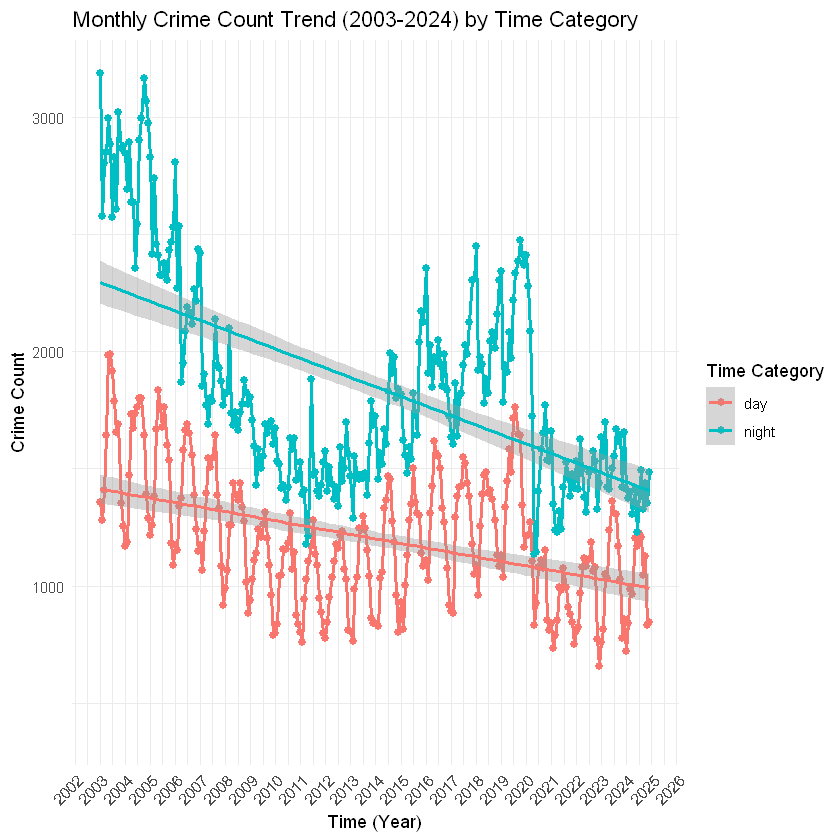

In [4]:
crime_trend <- crime_all|>
    group_by(time_category, year, month)|>
    summarise(crime_count = n(), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))

ggplot(crime_trend, aes(x = date, y = crime_count, color = time_category, group = time_category)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2003-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2003-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 318 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 318 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 318 rows containing missing values or values outside the scale range
(`geom_point()`)."


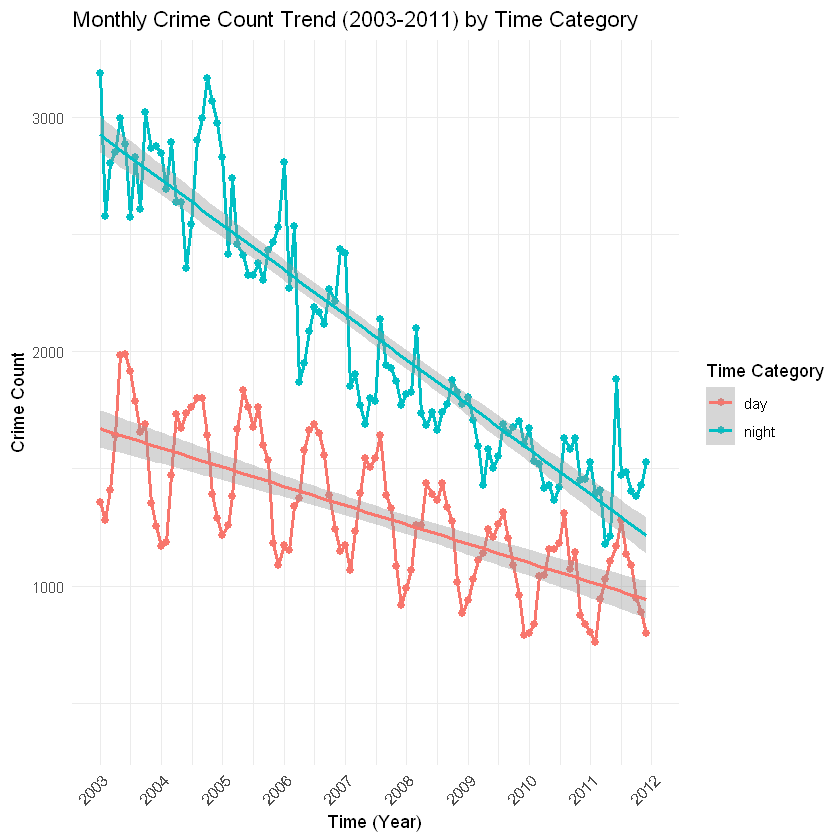

In [5]:
ggplot(crime_trend, aes(x = date, y = crime_count, color = time_category, group = time_category)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2003-01-01", "2011-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2003-2011) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 246 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 246 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 246 rows containing missing values or values outside the scale range
(`geom_point()`)."


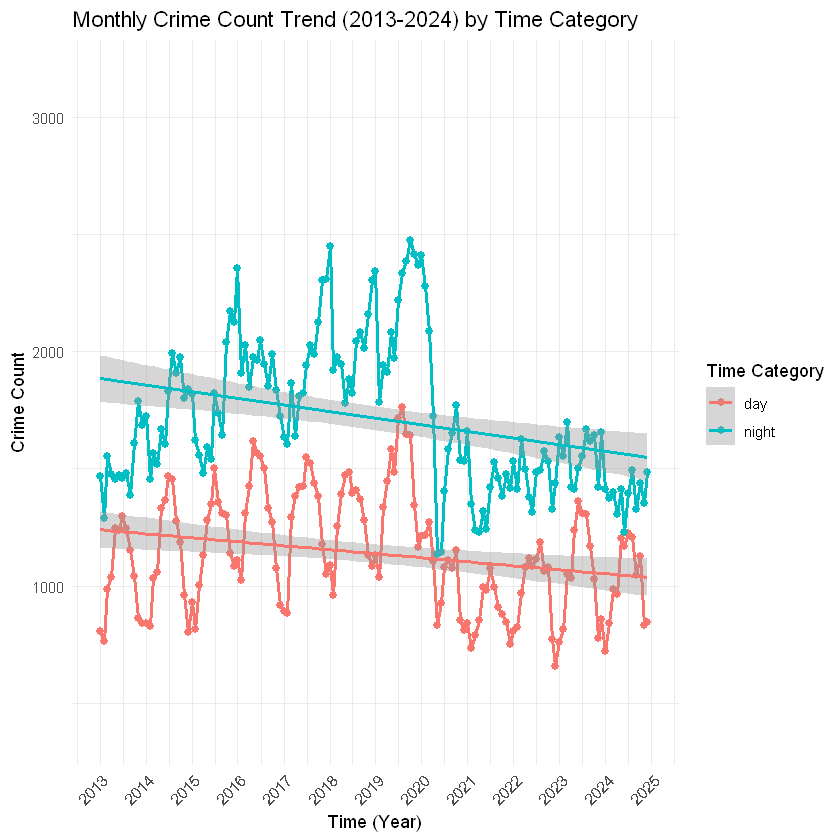

In [6]:
ggplot(crime_trend, aes(x = date, y = crime_count, color = time_category, group = time_category)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2013-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [7]:
lum_data <- read_csv("NTL_data/ntl_vancouver_monthly_total_ntl.csv")|>
    glimpse()

Rows: 78 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (4): total_ntl, total_pixels, weighted_ntl_mean, prev_weighted_ntl_mean
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 78
Columns: 5
$ date                   <date> 2012-01-01, 2012-03-01, 2012-05-01, 2012-07-01…
$ total_ntl              <dbl> NA, 9.5066512, -3.7940151, 1.8771791, 9.7744734…
$ total_pixels           <dbl> 3650, 3853, 3868, 3868, 3868, 3434, 3862, 3861,…
$ weighted_ntl_mean      <dbl> 4.522459, 4.952393, 4.764499, 4.853937, 5.32838…
$ prev_weighted_ntl_mean <dbl> NA, 4.522459, 4.952393, 4.764499, 4.853937, 5.3…


`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 6 rows containing non-finite outside the scale range (`stat_smooth()`)."
Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`)."


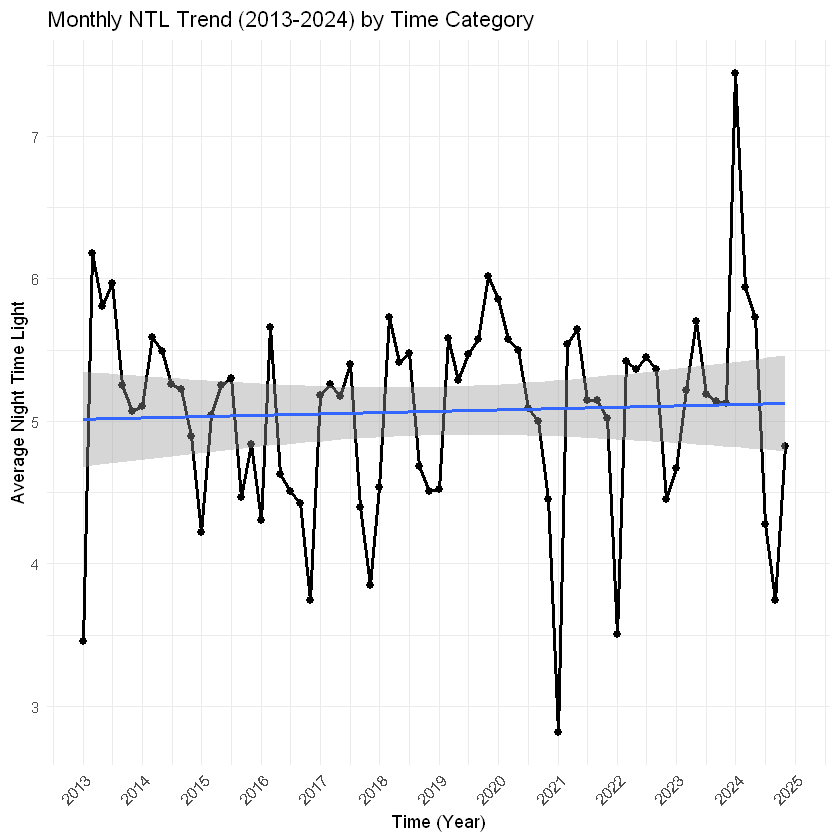

In [8]:
ggplot(lum_data, aes(x = date, y = weighted_ntl_mean)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Average Night Time Light", 
       title = "Monthly NTL Trend (2013-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

,date,time_category,year,month,crime_count,total_ntl,total_pixels,weighted_ntl_mean,prev_weighted_ntl_mean
,<date>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,2012-01-01,day,2012,1,774,NA,3650,4.522459,NA
2,2012-01-01,night,2012,1,1574,NA,3650,4.522459,NA
3,2012-03-01,night,2012,3,1507,9.506651,3853,4.952393,4.522459
4,2012-03-01,day,2012,3,953,9.506651,3853,4.952393,4.522459
5,2012-05-01,day,2012,5,1103,-3.794015,3868,4.764499,4.952393
6,2012-05-01,night,2012,5,1368,-3.794015,3868,4.764499,4.952393



Call:
lm(formula = crime_count ~ weighted_ntl_mean, data = merged_data)

Residuals:
   Min     1Q Median     3Q    Max 
-739.1 -300.9  -37.7  224.1 1030.9 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)        1357.53     237.88   5.707 5.74e-08 ***
weighted_ntl_mean    13.78      46.71   0.295    0.768    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 406.5 on 154 degrees of freedom
Multiple R-squared:  0.0005648,	Adjusted R-squared:  -0.005925 
F-statistic: 0.08704 on 1 and 154 DF,  p-value: 0.7684


`geom_smooth()` using formula = 'y ~ x'


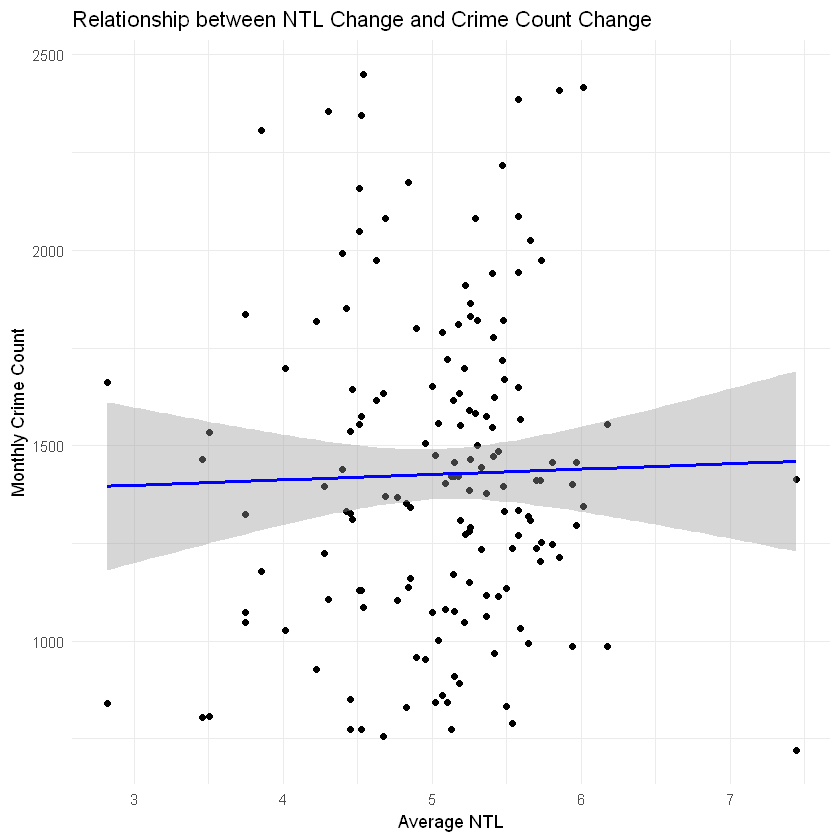

In [9]:
# Since both datasets have a date variable (format similar to "1月 2012"), we can use it to merge the data
merged_data <- merge(crime_trend, lum_data, by = "date")

# Check merge results
head(merged_data)

# Note:
# In the merged data, variables with the same name from both files will automatically get .x and .y suffixes
# Here, crime data percent change is pct_change.x, ntl is pct_change.y


# Run linear regression, using NTL percent change to predict crime rate percent change
reg_model <- lm(crime_count ~ weighted_ntl_mean, data = merged_data)
summary(reg_model)

# Create scatter plot with regression line
ggplot(merged_data, aes(x = weighted_ntl_mean, y = crime_count)) +
  geom_point() +
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  labs(x = "Average NTL", y = "Monthly Crime Count",
       title = "Relationship between NTL Change and Crime Count Change") +
  theme_minimal()


In [10]:
crime_summary_neighbourhood <- crime_all|>
    filter(year != 2025)|>
    filter(!geo_local_area %in% c(NA, "Musqueam", "Stanley Park"))|>
    group_by(geo_local_area)|>
    summarise(crime_count = n())|>
    arrange(desc(crime_count))

print(crime_summary_neighbourhood)

# A tibble: 22 × 2
   geo_local_area           crime_count
   <chr>                          <int>
 1 Downtown                      221662
 2 West End                       73711
 3 Fairview                       51612
 4 Mount Pleasant                 50280
 5 Strathcona                     46084
 6 Grandview-Woodland             46030
 7 Renfrew-Collingwood            42222
 8 Kitsilano                      41390
 9 Kensington-Cedar Cottage       33436
10 Hastings-Sunrise               28159
# ℹ 12 more rows


In [11]:
daily_ntl <- read_csv("NTL_data/ntl_2012_2024_daily.csv")|>
    filter(!is.na(ntl_mean))|>
    glimpse()

Rows: 4749 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (4): ntl_mean, n_pixels, n_non_na_pixels, prop_non_na_pixels
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3,830
Columns: 5
$ ntl_mean           <dbl> 4.346262, 4.281751, 4.284582, 4.283045, 4.015064, 4…
$ n_pixels           <dbl> 907, 907, 907, 907, 907, 907, 907, 907, 907, 907, 9…
$ n_non_na_pixels    <dbl> 887, 890, 891, 889, 905, 905, 907, 903, 903, 904, 9…
$ prop_non_na_pixels <dbl> 0.9779493, 0.9812569, 0.9823594, 0.9801544, 0.99779…
$ date               <date> 2012-01-19, 2012-01-20, 2012-01-21, 2012-01-22, 20…


`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 275 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 275 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 275 rows containing missing values or values outside the scale range
(`geom_point()`)."


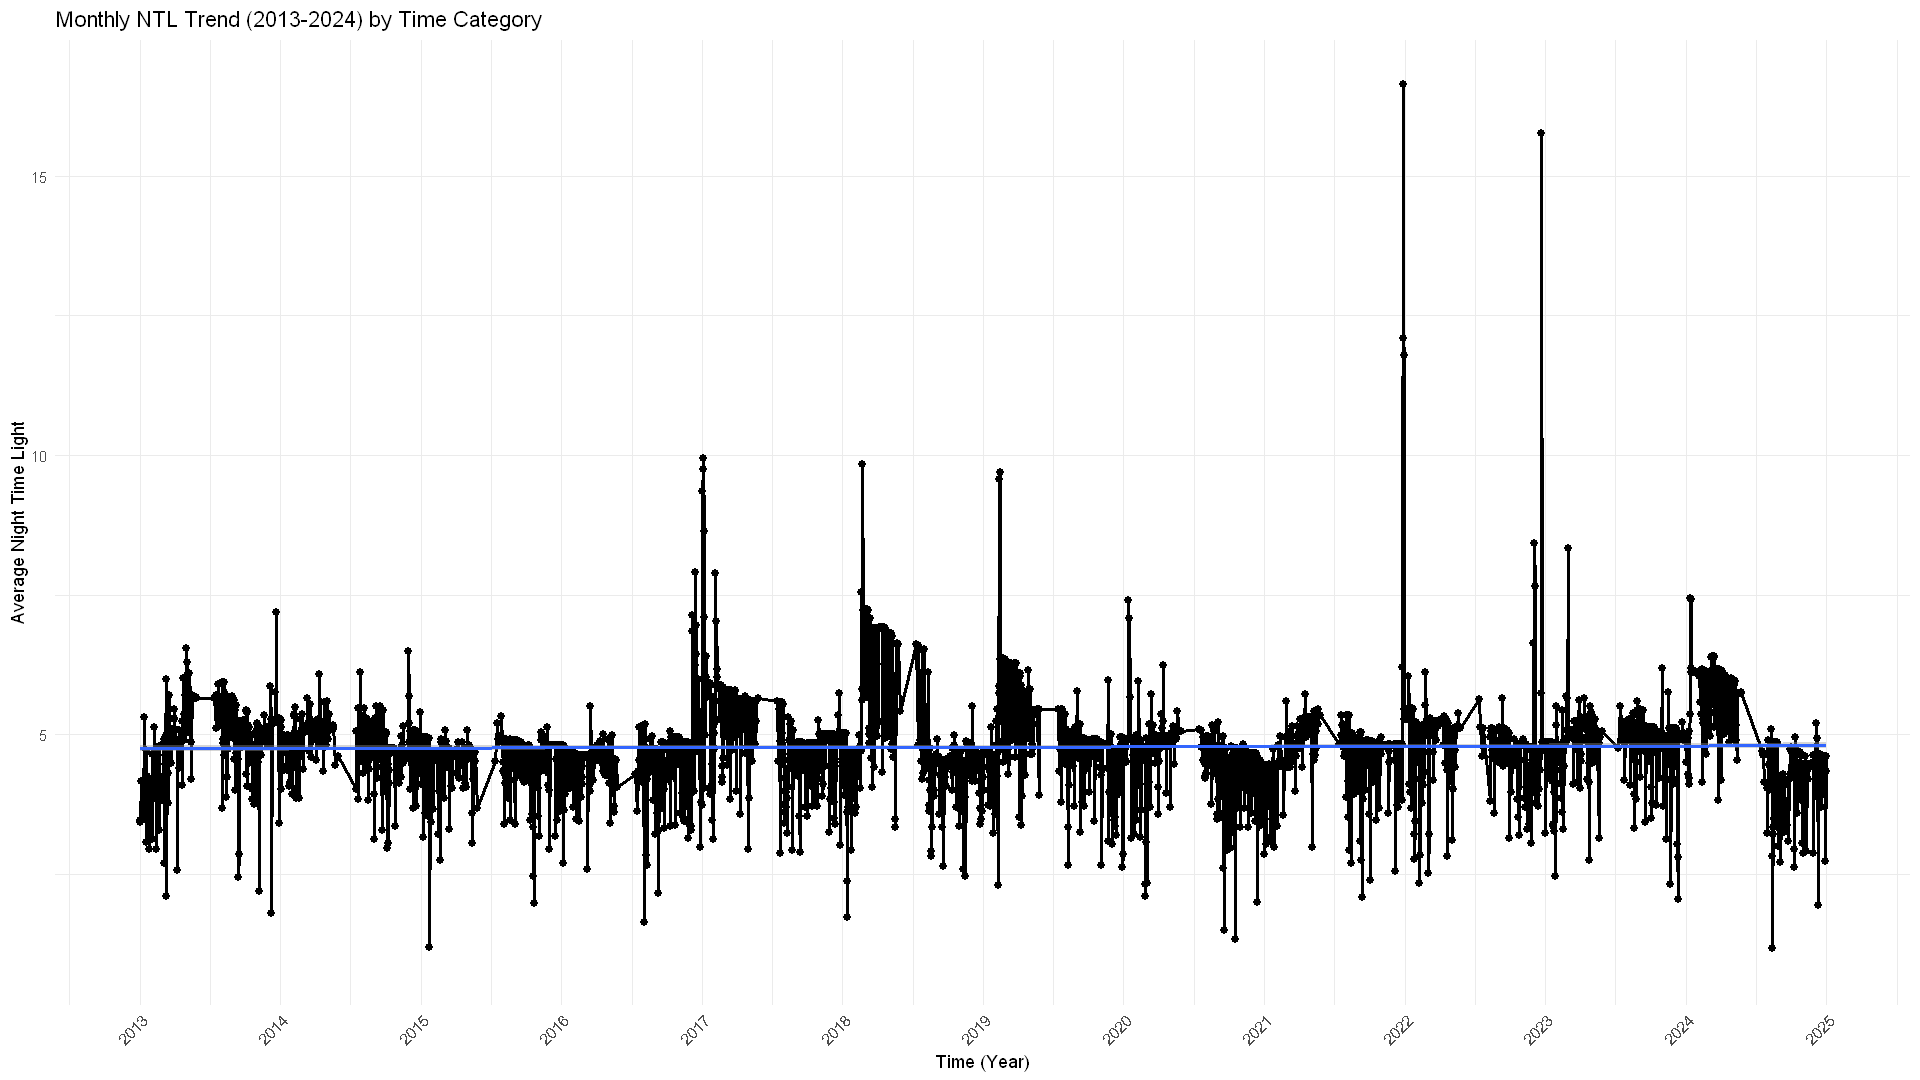

In [12]:
options(repr.plot.width = 16, repr.plot.height = 9)

ggplot(daily_ntl, aes(x = date, y = ntl_mean)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Average Night Time Light", 
       title = "Monthly NTL Trend (2013-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [13]:
daily_ntl <- daily_ntl|>
    arrange(desc(ntl_mean))

head(daily_ntl, 10)

ntl_mean,n_pixels,n_non_na_pixels,prop_non_na_pixels,date
<dbl>,<dbl>,<dbl>,<dbl>,<date>
16.649954,907,905,0.9977949,2021-12-27
15.769461,907,904,0.9966924,2022-12-22
12.100985,907,903,0.9955899,2021-12-28
11.797810,907,903,0.9955899,2021-12-29
9.943578,907,904,0.9966924,2017-01-04
9.845053,907,900,0.9922822,2018-02-22
9.748865,907,904,0.9966924,2017-01-03
9.692175,907,905,0.9977949,2019-02-14
9.578393,907,904,0.9966924,2019-02-11


In [14]:
ntl_12_24_monthly <- read_csv("NTL_data/22_ntl_2012_2024_monthly.csv")|>
    filter(!is.na(ntl_mean))|>
    mutate(date = as.Date(paste0(date, "-01"), format = "%Y-%m-%d"))|>
    glimpse()

Rows: 3432 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): name, geo_point_2d, date
dbl (4): ntl_mean, n_pixels, n_non_na_pixels, prop_non_na_pixels

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3,146
Columns: 7
$ name               <chr> "Downtown", "Hastings-Sunrise", "Kerrisdale", "Marp…
$ geo_point_2d       <chr> "{ \"lon\": -123.11656700827415, \"lat\": 49.280747…
$ ntl_mean           <dbl> 15.101049, 3.424347, 2.195419, 4.155951, 3.277409, …
$ n_pixels           <dbl> 54, 71, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 69,…
$ n_non_na_pixels    <dbl> 54, 53, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 45,…
$ prop_non_na_pixels <dbl> 1.0000000, 0.7464789, 1.0000000, 1.0000000, 1.00000…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


Warning message:
"Removed 242 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 242 rows containing missing values or values outside the scale range
(`geom_point()`)."


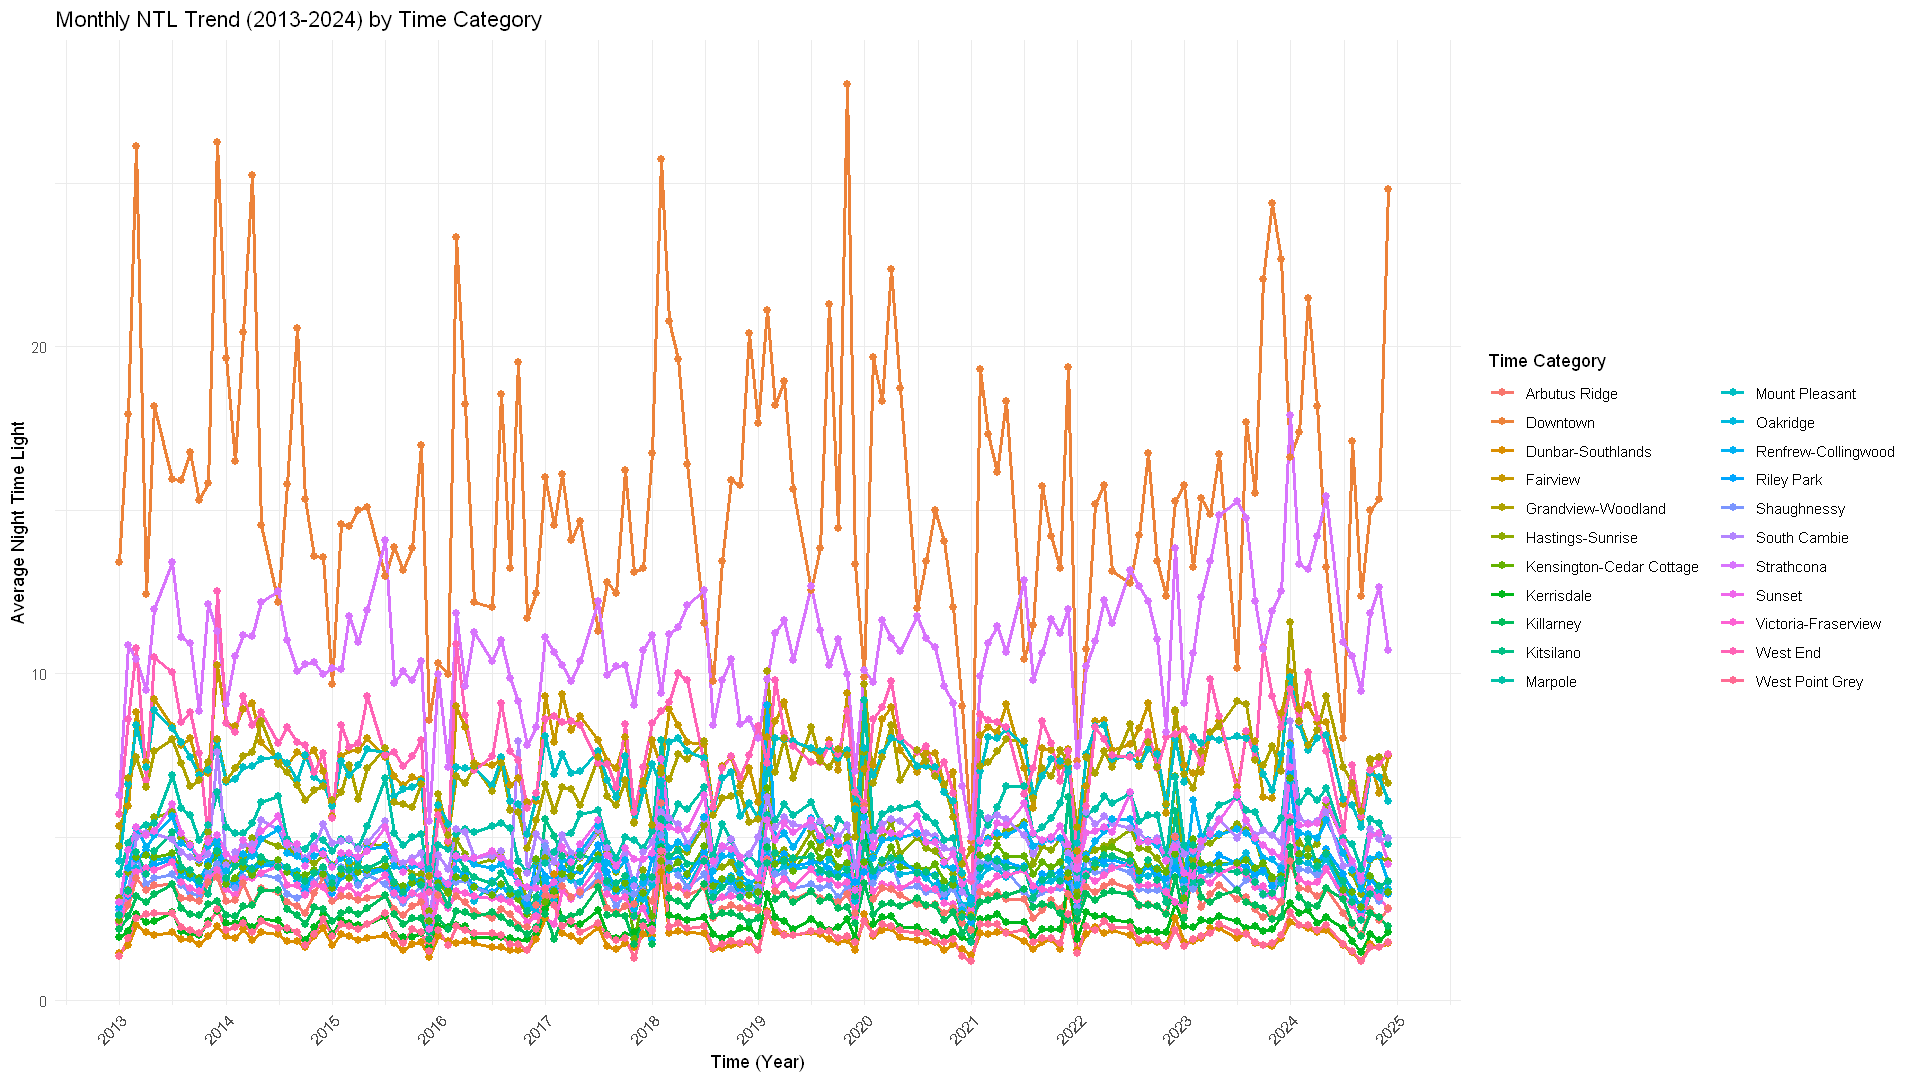

In [15]:
options(repr.plot.width = 16, repr.plot.height = 9)

ggplot(ntl_12_24_monthly, aes(x = date, y = ntl_mean, color = name, group = name)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
#   geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Average Night Time Light", 
       title = "Monthly NTL Trend (2013-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [16]:
crime_trend_neighborhood <- crime_all|>
    filter(!is.na(geo_local_area))|>
    group_by(time_category, year, month, geo_local_area)|>
    summarise(crime_count = n(), .groups = "drop")|>
    ungroup()|>
    filter(time_category == "night")|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()


Rows: 5,874
Columns: 6
$ time_category  <chr> "night", "night", "night", "night", "night", "night", "…
$ year           <dbl> 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2…
$ month          <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ geo_local_area <chr> "Arbutus Ridge", "Downtown", "Dunbar-Southlands", "Fair…
$ crime_count    <int> 52, 740, 67, 201, 229, 126, 143, 38, 77, 235, 87, 123, …
$ date           <date> 2003-01-01, 2003-01-01, 2003-01-01, 2003-01-01, 2003-0…


Warning message:
"Removed 66 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 66 rows containing missing values or values outside the scale range
(`geom_point()`)."


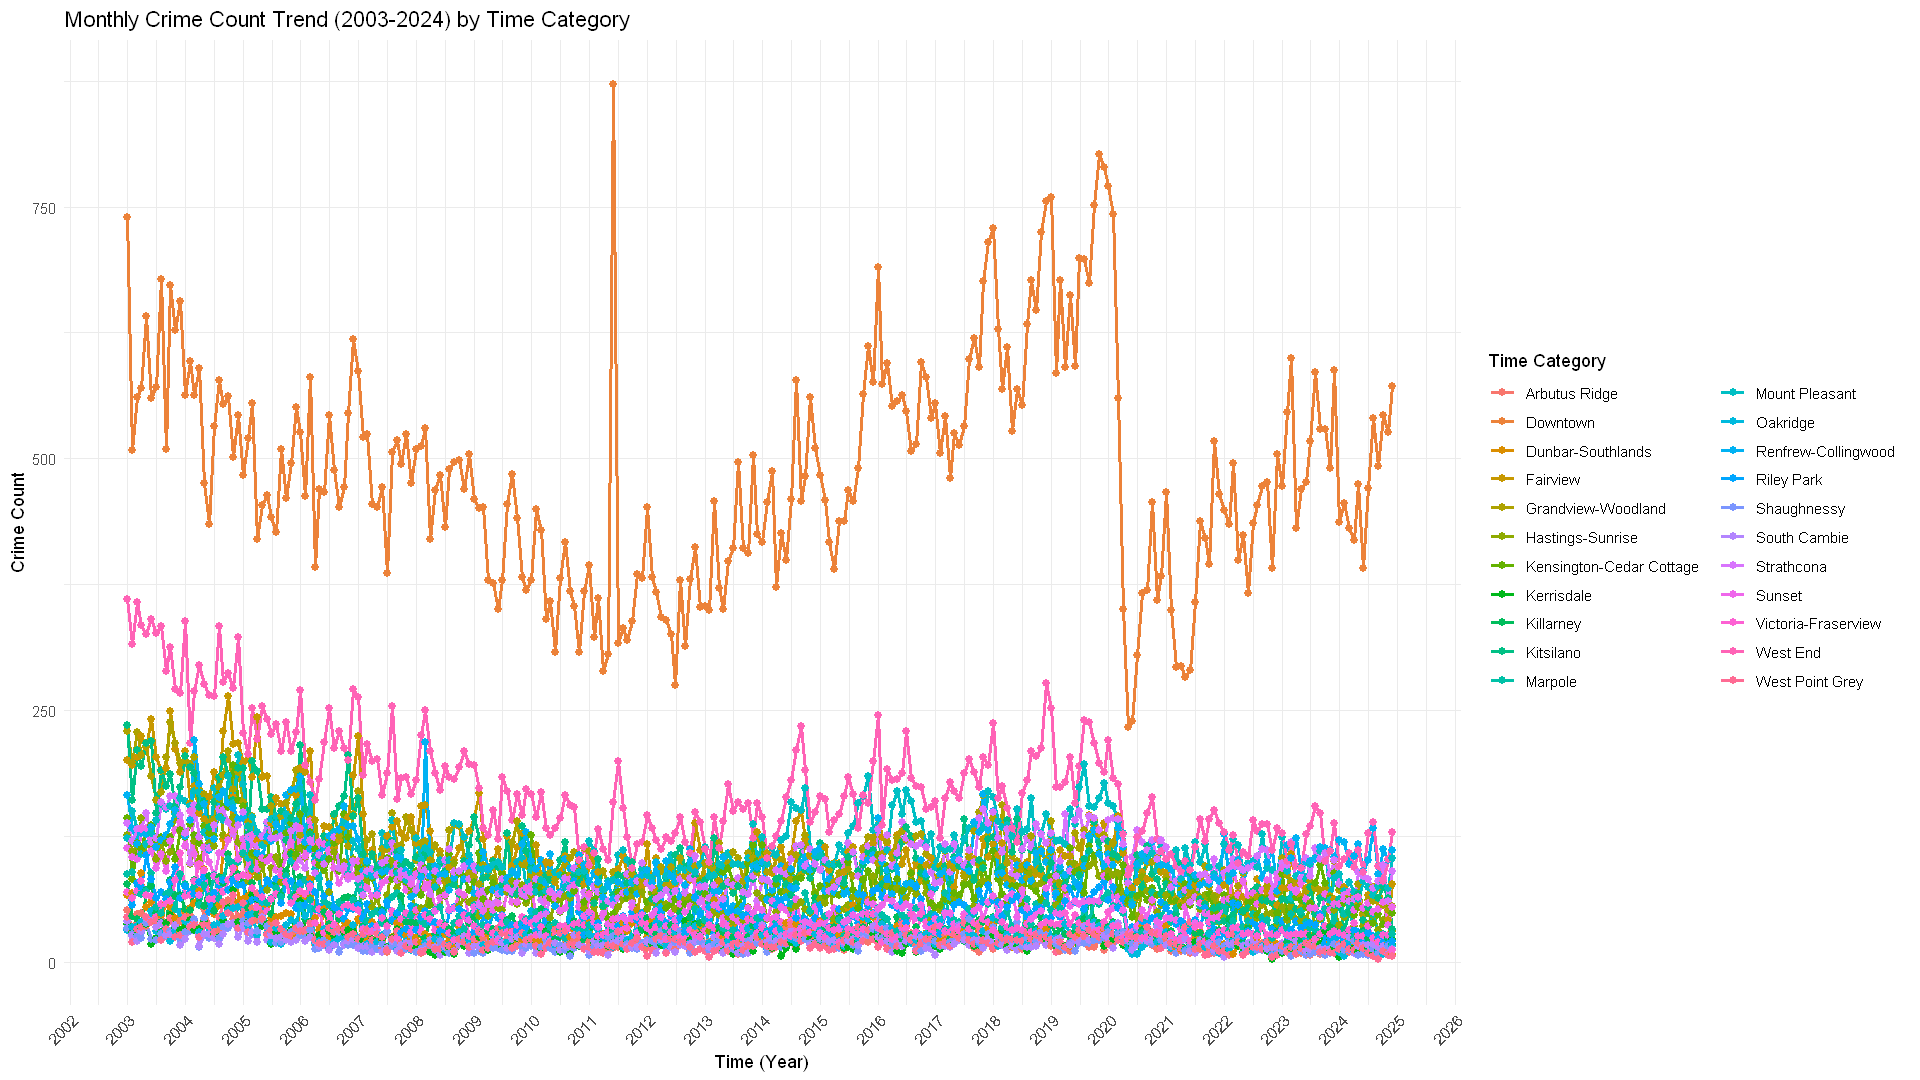

In [17]:

ggplot(crime_trend_neighborhood, aes(x = date, y = crime_count, color = geo_local_area, group = geo_local_area)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
#   geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2003-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2003-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [18]:
crime_trend_dt_sc <- crime_all|>
    filter(geo_local_area %in% c("Downtown", "South Cambie"))|>
    group_by(time_category, year, month, geo_local_area)|>
    summarise(crime_count = n(), .groups = "drop")|>
    mutate(log_crime_count = log(crime_count))|>
    ungroup()|>
    filter(time_category == "night")|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 534
Columns: 7
$ time_category   <chr> "night", "night", "night", "night", "night", "night", …
$ year            <dbl> 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, …
$ month           <dbl> 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, …
$ geo_local_area  <chr> "Downtown", "South Cambie", "Downtown", "South Cambie"…
$ crime_count     <int> 740, 41, 508, 26, 561, 21, 570, 31, 641, 44, 560, 41, …
$ log_crime_count <dbl> 6.606650, 3.713572, 6.230481, 3.258097, 6.329721, 3.04…
$ date            <date> 2003-01-01, 2003-01-01, 2003-02-01, 2003-02-01, 2003-…


In [19]:
ntl_monthly_dt_sc <- ntl_12_24_monthly|>
    filter(name %in% c("Downtown", "South Cambie"))

Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`)."


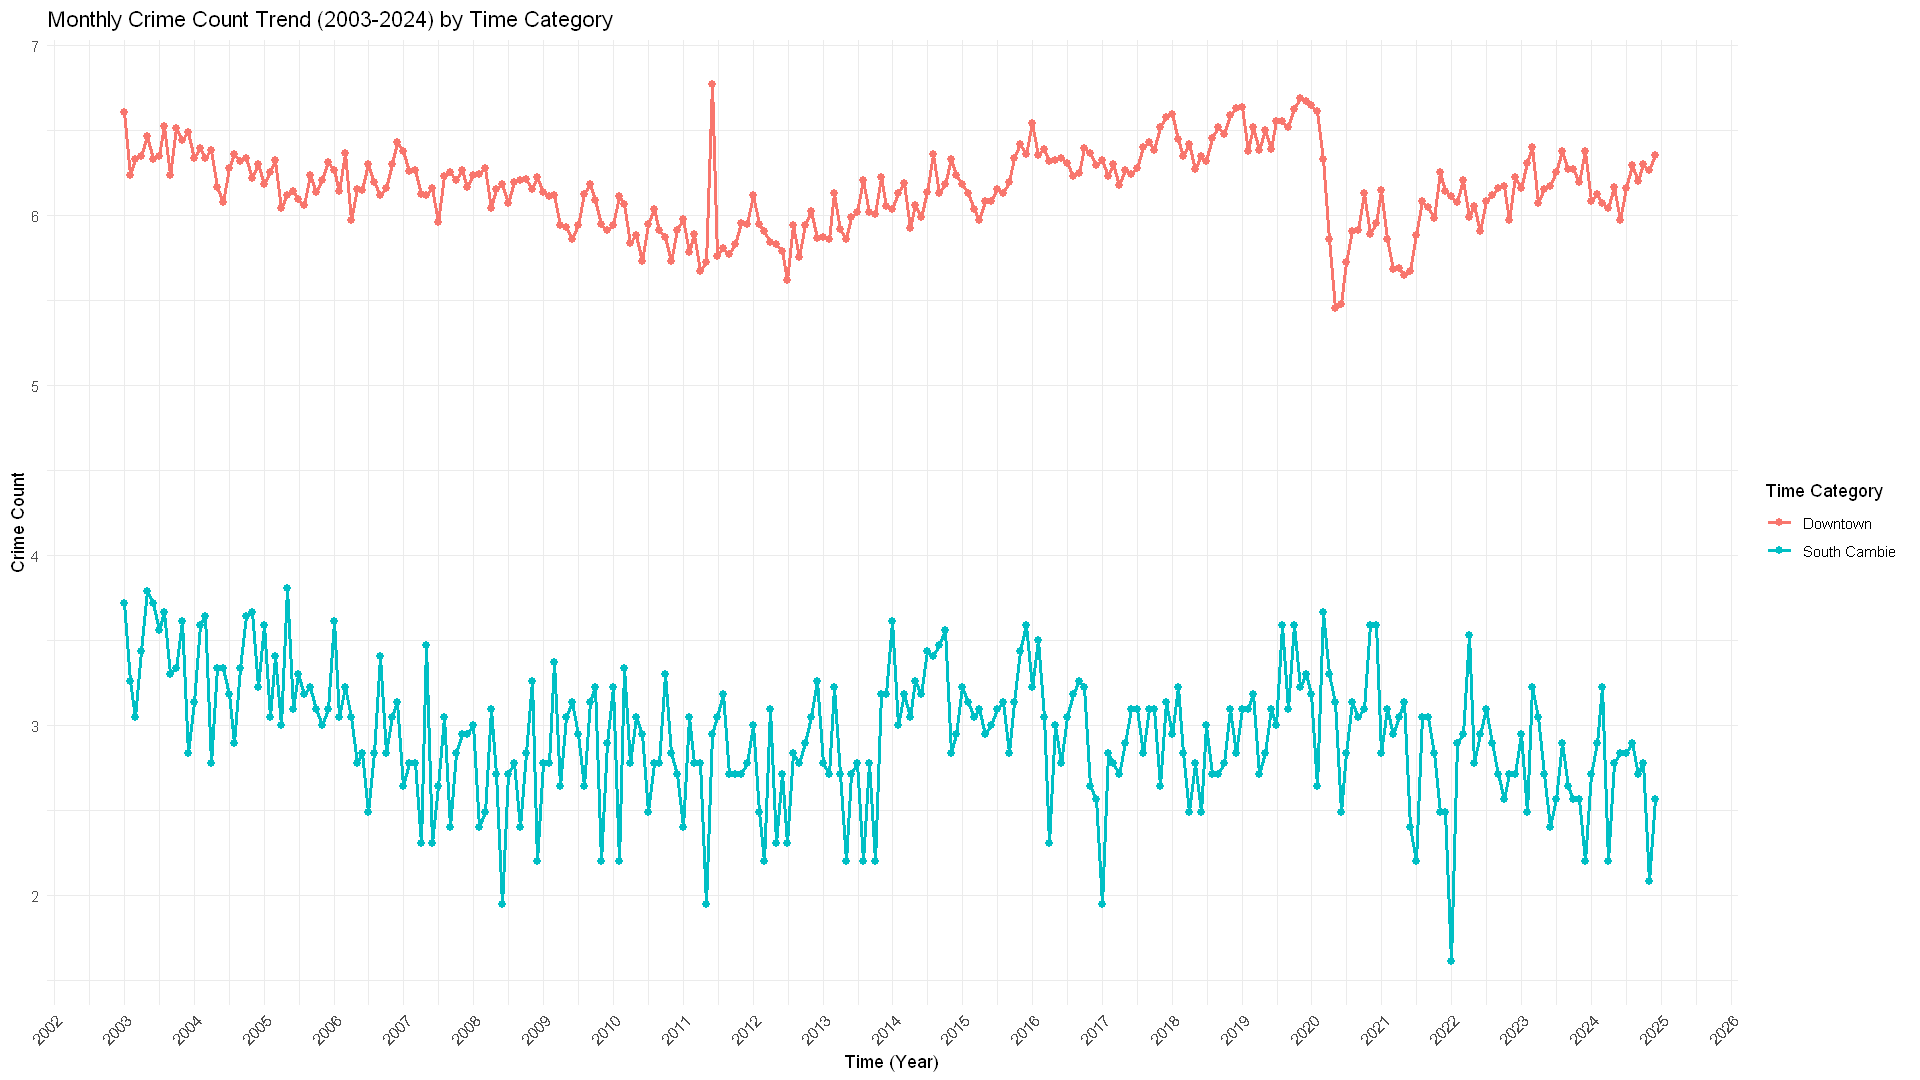

In [20]:
ggplot(crime_trend_dt_sc, aes(x = date, y = log_crime_count, color = geo_local_area, group = geo_local_area)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
#   geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2003-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2003-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) 

Warning message:
"Removed 22 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 22 rows containing missing values or values outside the scale range
(`geom_point()`)."


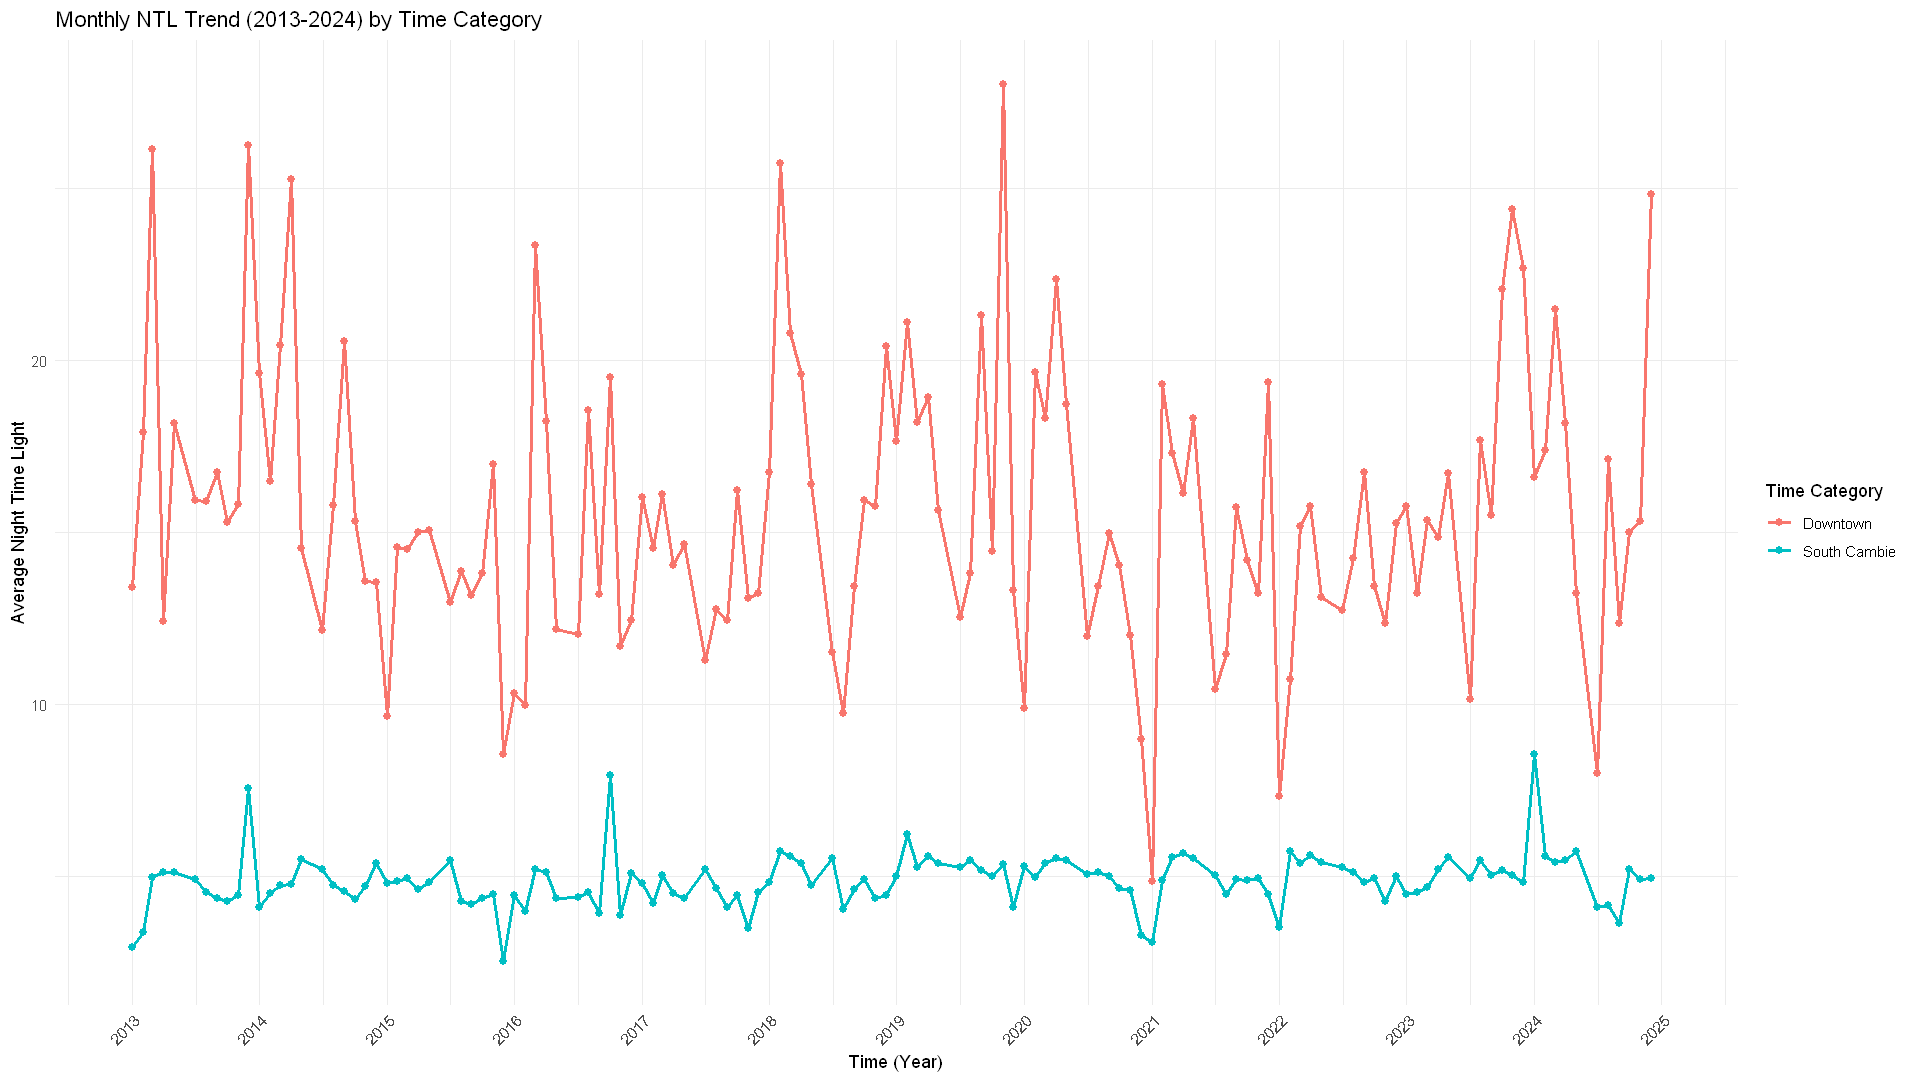

In [21]:
options(repr.plot.width = 16, repr.plot.height = 9)

ggplot(ntl_monthly_dt_sc, aes(x = date, y = ntl_mean, color = name, group = name)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
#   geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Average Night Time Light", 
       title = "Monthly NTL Trend (2013-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Poisson Model

In [22]:
crime_monthly <- read.csv("Original_Crime_data/crime_in_vancouver.csv")|>
    select(type, year, month, geo_local_area, time_category)|>
    filter(!is.na(geo_local_area))|>
    group_by(year, month, geo_local_area, time_category)|>
    summarise(crime_count = n(), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    mutate(geo_local_area = as.factor(geo_local_area))|>
    glimpse()

Rows: 11,747
Columns: 6
$ year           <int> 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2…
$ month          <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ geo_local_area <fct> Arbutus Ridge, Arbutus Ridge, Downtown, Downtown, Dunba…
$ time_category  <chr> "day", "night", "day", "night", "day", "night", "day", …
$ crime_count    <int> 30, 52, 353, 740, 22, 67, 102, 201, 85, 229, 36, 126, 5…
$ date           <date> 2003-01-01, 2003-01-01, 2003-01-01, 2003-01-01, 2003-0…


In [23]:
crime_monthly$year <- as.factor(crime_monthly$year)
crime_monthly$month <- as.factor(crime_monthly$month)
crime_monthly$time_category <- as.factor(crime_monthly$time_category)

In [24]:
install.packages("fixest")

Installing package into 'C:/Users/Kaiyan Zhang/AppData/Local/R/win-library/4.4'
(as 'lib' is unspecified)



package 'fixest' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'fixest'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\Kaiyan Zhang\AppData\Local\R\win-library\4.4\00LOCK\fixest\libs\x64\fixest.dll to C:\Users\Kaiyan Zhang\AppData\Local\R\win-library\4.4\fixest\libs\x64\fixest.dll: Permission denied"
Warning message:
"restored 'fixest'"



The downloaded binary packages are in
	C:\Users\Kaiyan Zhang\AppData\Local\Temp\Rtmpa26s0S\downloaded_packages


In [25]:
library(fixest)

Warning message:
"package 'fixest' was built under R version 4.4.3"


In [26]:
model_fe <- feglm(crime_count ~ 1, data = crime_monthly, family = poisson(), fixef = c("geo_local_area", "year", "month", "time_category"))

summary(model_fe)

GLM estimation, family = poisson, Dep. Var.: crime_count
Observations: 11,747
Fixed-effects: geo_local_area: 22,  year: 23,  month: 12,  time_category: 2
Log-Likelihood: -59,969.9   Adj. Pseudo R2: 0.869886
           BIC: 120,464.5     Squared Cor.: 0.917063

In [27]:
crime_monthly$predicted_lambda <- predict(model_fe, type = "response")

glimpse(crime_monthly)

Rows: 11,747
Columns: 7
$ year             <fct> 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003,…
$ month            <fct> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ geo_local_area   <fct> Arbutus Ridge, Arbutus Ridge, Downtown, Downtown, Dun…
$ time_category    <fct> day, night, day, night, day, night, day, night, day, …
$ crime_count      <int> 30, 52, 353, 740, 22, 67, 102, 201, 85, 229, 36, 126,…
$ date             <date> 2003-01-01, 2003-01-01, 2003-01-01, 2003-01-01, 2003…
$ predicted_lambda <dbl> 19.75231, 30.70187, 477.74824, 742.58470, 26.89805, 4…


In [28]:
poisson_summary <- crime_monthly|>
    group_by(time_category)|>
    summarise(mean = mean(predicted_lambda),
    variance = var(predicted_lambda))

poisson_summary

time_category,mean,variance
<fct>,<dbl>,<dbl>
day,53.72314,4583.804
night,83.49421,11073.092


Warning message:
"Removed 5412 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 5412 rows containing missing values or values outside the scale range
(`geom_point()`)."


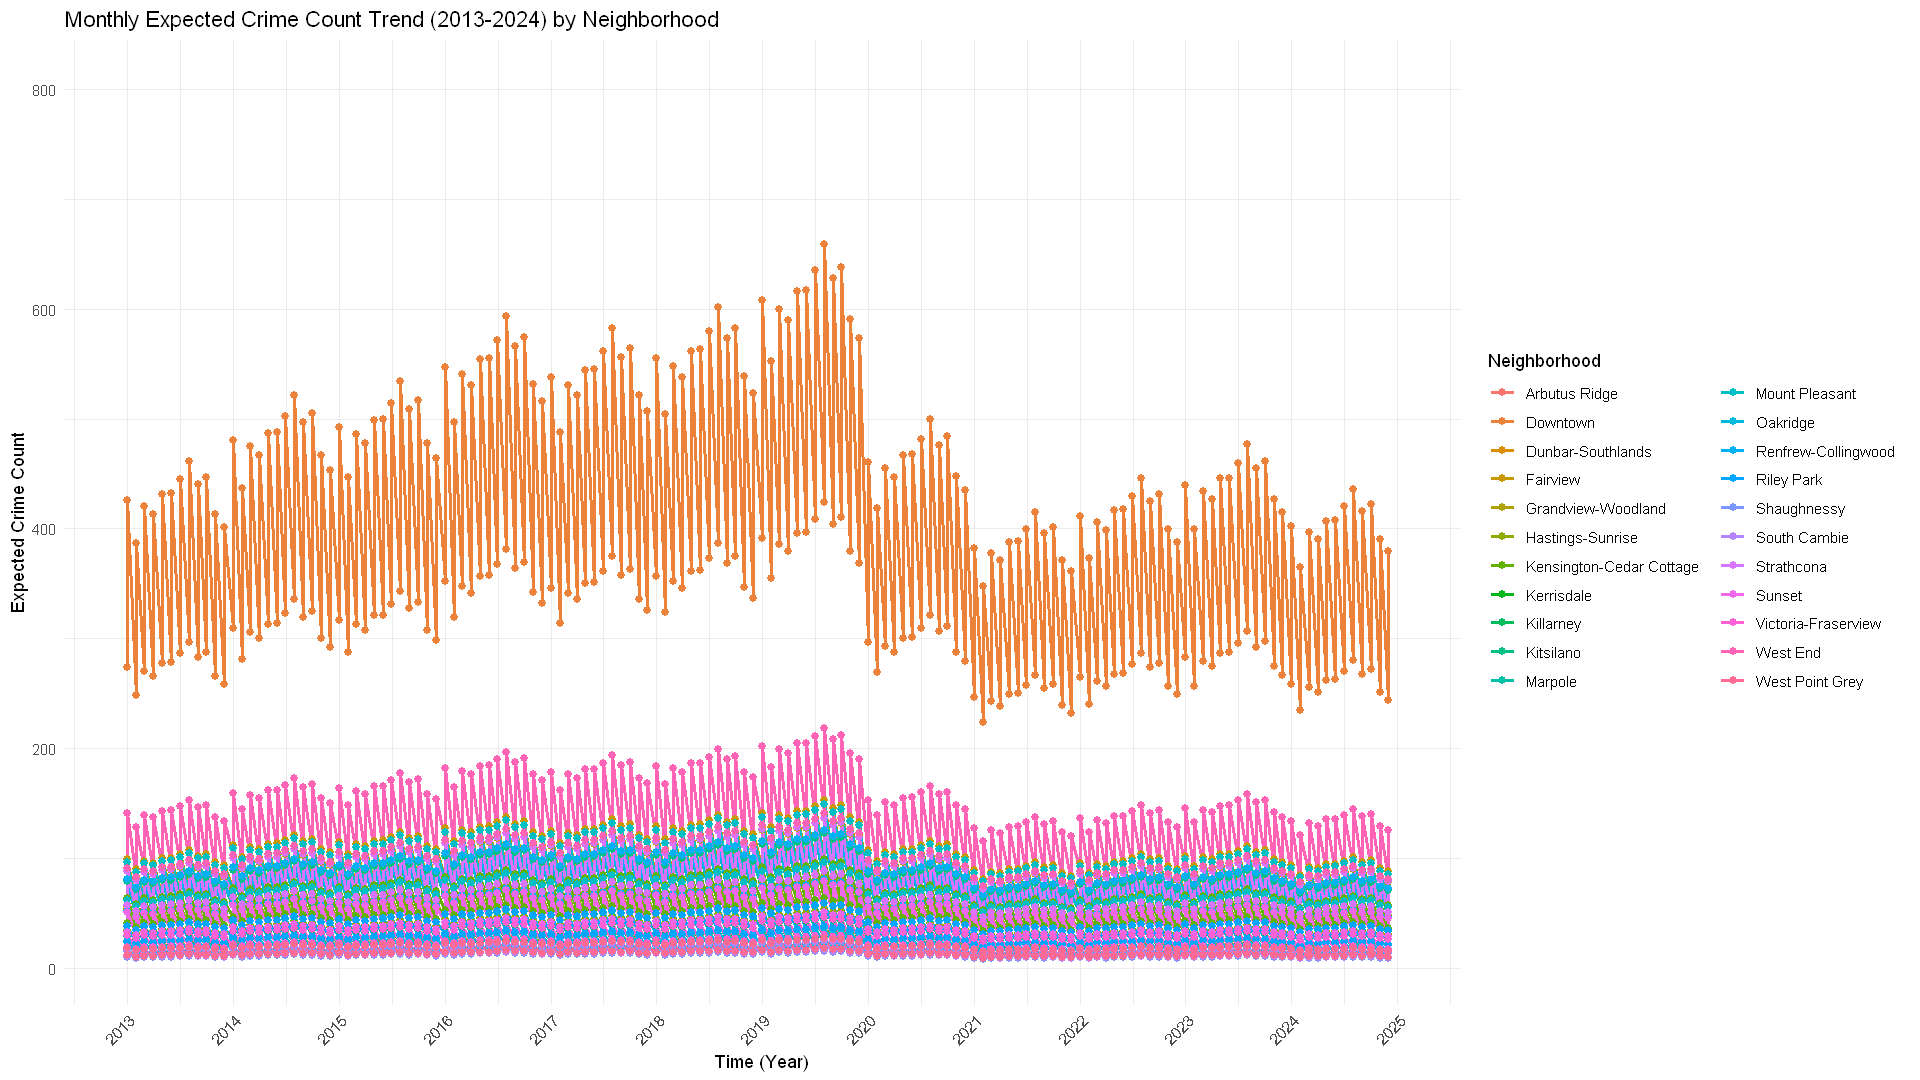

In [29]:
ggplot(crime_monthly, aes(x = date, y = predicted_lambda, color = geo_local_area, group = geo_local_area)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  # geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2013-2024) by Neighborhood",
       color = "Neighborhood") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

Warning message:
"Removed 2706 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 2706 rows containing missing values or values outside the scale range
(`geom_point()`)."


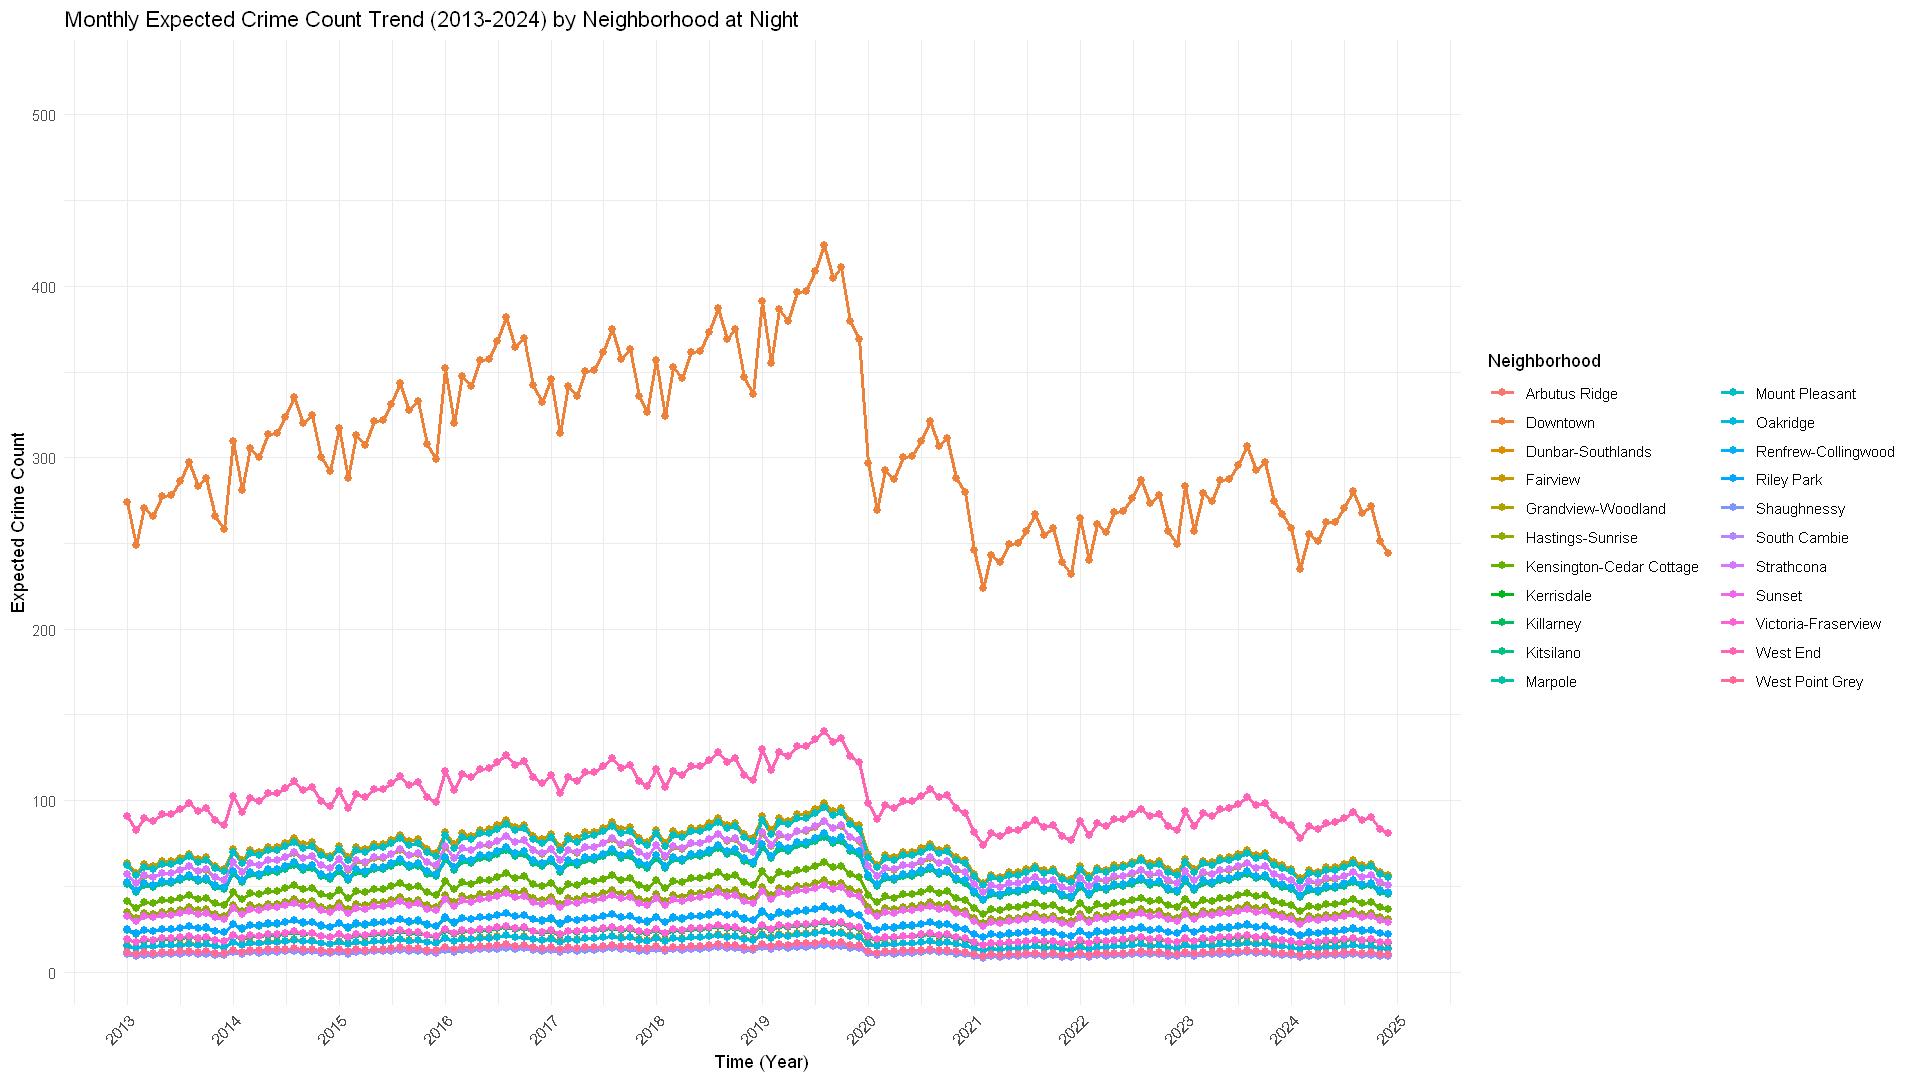

In [30]:
crime_monthly_day <- crime_monthly|>
    filter(time_category == "day")

ggplot(crime_monthly_day, aes(x = date, y = predicted_lambda, color = geo_local_area, group = geo_local_area)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  # geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2013-2024) by Neighborhood at Night",
       color = "Neighborhood") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

Warning message:
"Removed 2706 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 2706 rows containing missing values or values outside the scale range
(`geom_point()`)."


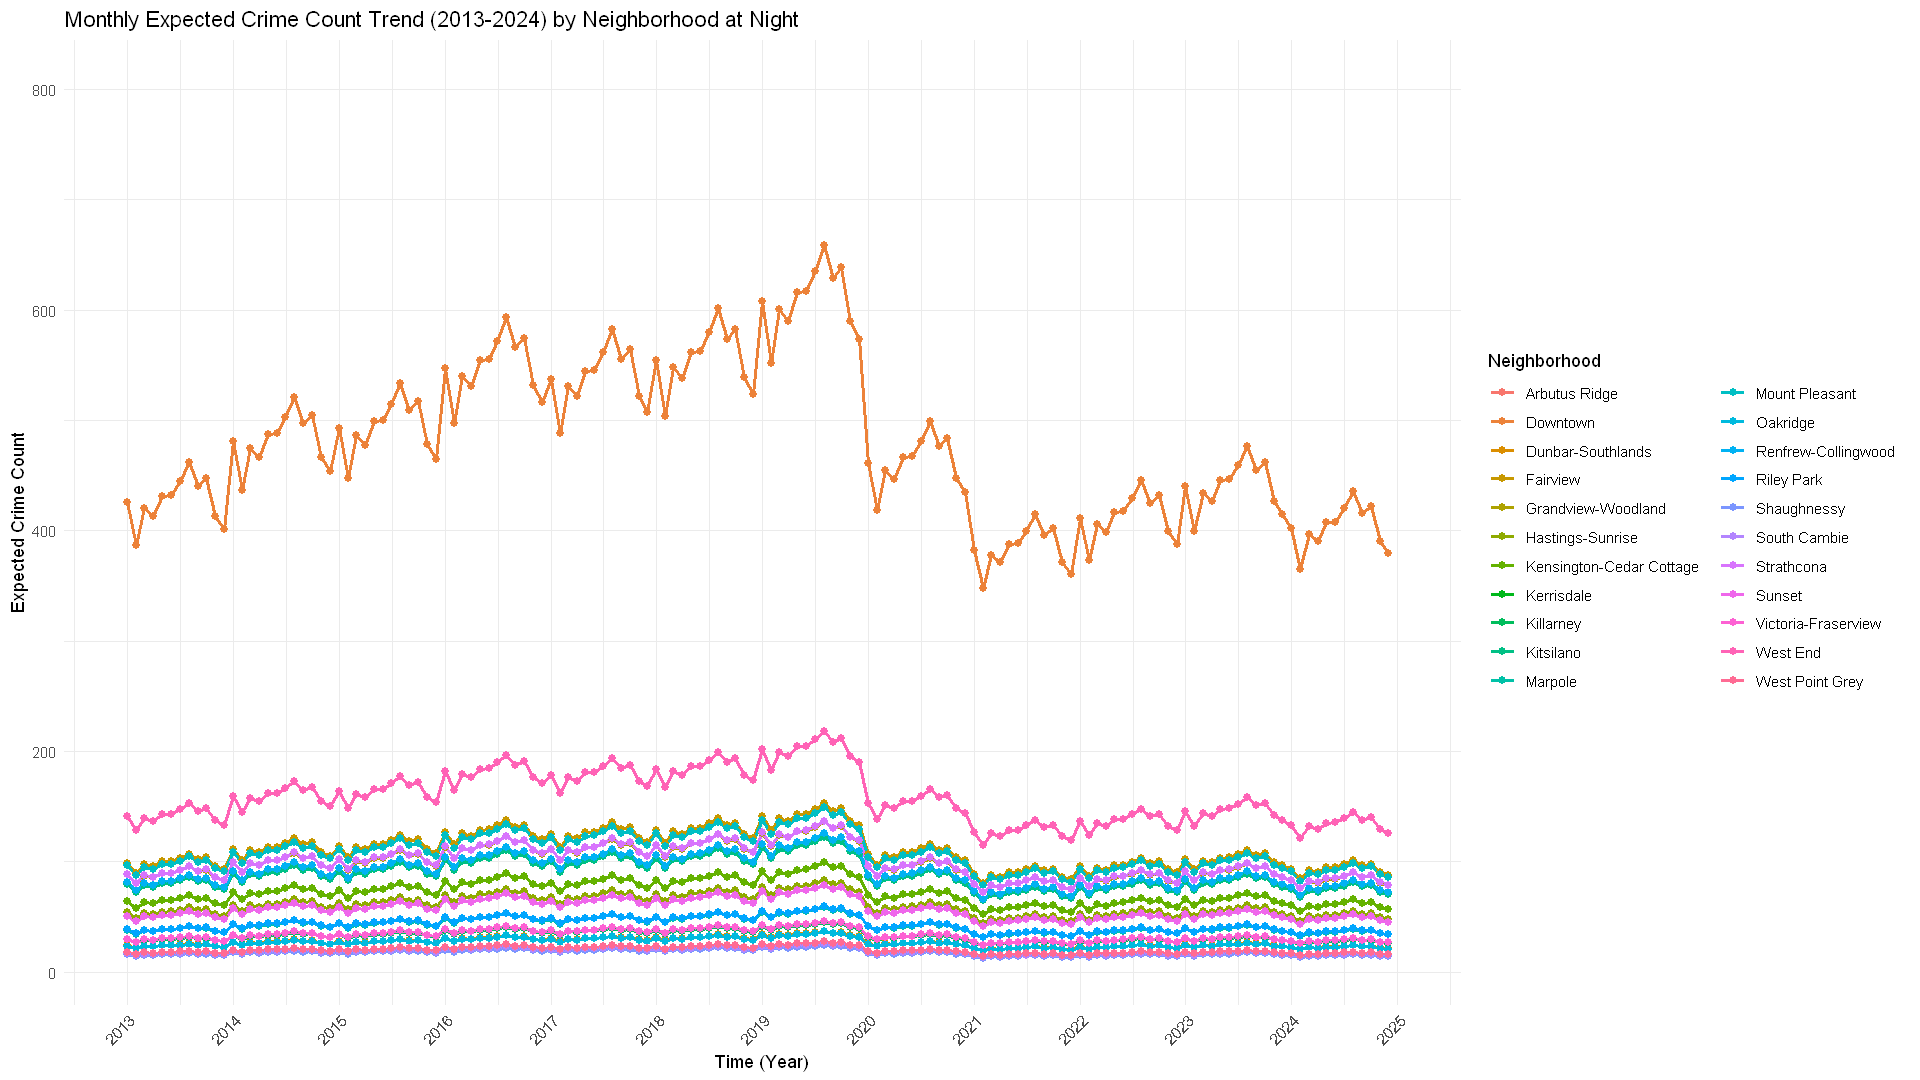

In [31]:
crime_monthly_night <- crime_monthly|>
    filter(time_category == "night")

ggplot(crime_monthly_night, aes(x = date, y = predicted_lambda, color = geo_local_area, group = geo_local_area)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  # geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2013-2024) by Neighborhood at Night",
       color = "Neighborhood") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Negative Binomial Regression

In [32]:
library(MASS)

Warning message:
"package 'MASS' was built under R version 4.4.2"

Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select




In [33]:
model_nb <- glm.nb(crime_count ~ geo_local_area + year + month + time_category, data = crime_monthly)

summary(model_nb)


Call:
glm.nb(formula = crime_count ~ geo_local_area + year + month + 
    time_category, data = crime_monthly, init.theta = 17.9603945, 
    link = log)

Coefficients:
                                        Estimate Std. Error z value Pr(>|z|)
(Intercept)                             2.962961   0.020877 141.925  < 2e-16
geo_local_areaDowntown                  3.240656   0.018139 178.658  < 2e-16
geo_local_areaDunbar-Southlands         0.279318   0.020294  13.763  < 2e-16
geo_local_areaFairview                  1.746598   0.018576  94.023  < 2e-16
geo_local_areaGrandview-Woodland        1.612831   0.018655  86.455  < 2e-16
geo_local_areaHastings-Sunrise          1.106448   0.019061  58.049  < 2e-16
geo_local_areaKensington-Cedar Cottage  1.288165   0.018893  68.183  < 2e-16
geo_local_areaKerrisdale               -0.035893   0.021056  -1.705 0.088257
geo_local_areaKillarney                 0.500277   0.019872  25.176  < 2e-16
geo_local_areaKitsilano                 1.486988   0.018739  

In [34]:
crime_monthly$predicted_theta <- predict(model_nb, type = "response")

glimpse(crime_monthly)

Rows: 11,747
Columns: 8
$ year             <fct> 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003,…
$ month            <fct> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ geo_local_area   <fct> Arbutus Ridge, Arbutus Ridge, Downtown, Downtown, Dun…
$ time_category    <fct> day, night, day, night, day, night, day, night, day, …
$ crime_count      <int> 30, 52, 353, 740, 22, 67, 102, 201, 85, 229, 36, 126,…
$ date             <date> 2003-01-01, 2003-01-01, 2003-01-01, 2003-01-01, 2003…
$ predicted_lambda <dbl> 19.75231, 30.70187, 477.74824, 742.58470, 26.89805, 4…
$ predicted_theta  <dbl> 19.35520, 31.83776, 494.53464, 813.46995, 25.59198, 4…


In [35]:
NBsummary <- crime_monthly|>
    group_by(time_category)|>
    summarise(mean = mean(predicted_theta),
    variance = var(predicted_theta),
    min = min(predicted_theta),
    max = max(predicted_theta))

NBsummary

time_category,mean,variance,min,max
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
day,52.62353,4775.717,5.339344,547.5458
night,86.55068,12920.442,8.782795,900.6690


Warning message:
"Removed 5412 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 5412 rows containing missing values or values outside the scale range
(`geom_point()`)."


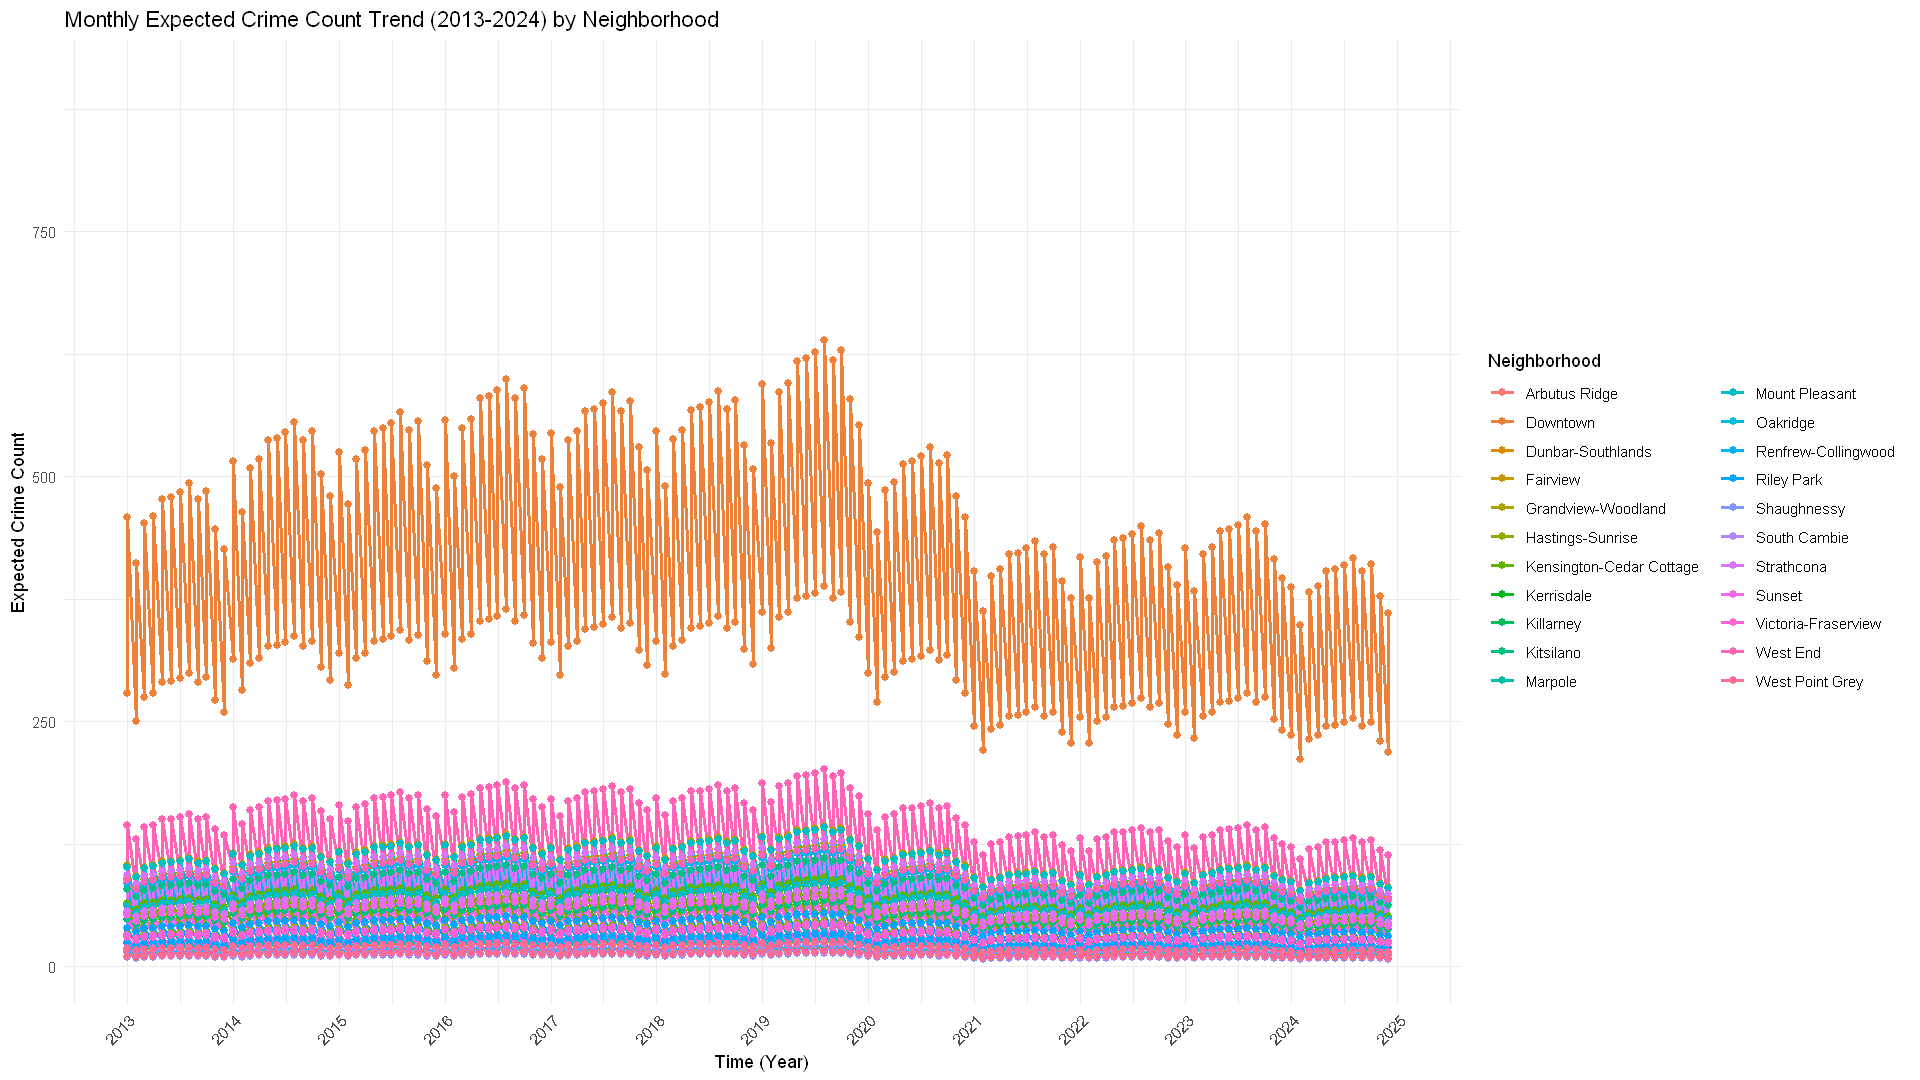

In [36]:
ggplot(crime_monthly, aes(x = date, y = predicted_theta, color = geo_local_area, group = geo_local_area)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  # geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2013-2024) by Neighborhood",
       color = "Neighborhood") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

Warning message:
"Removed 4554 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 4554 rows containing missing values or values outside the scale range
(`geom_point()`)."


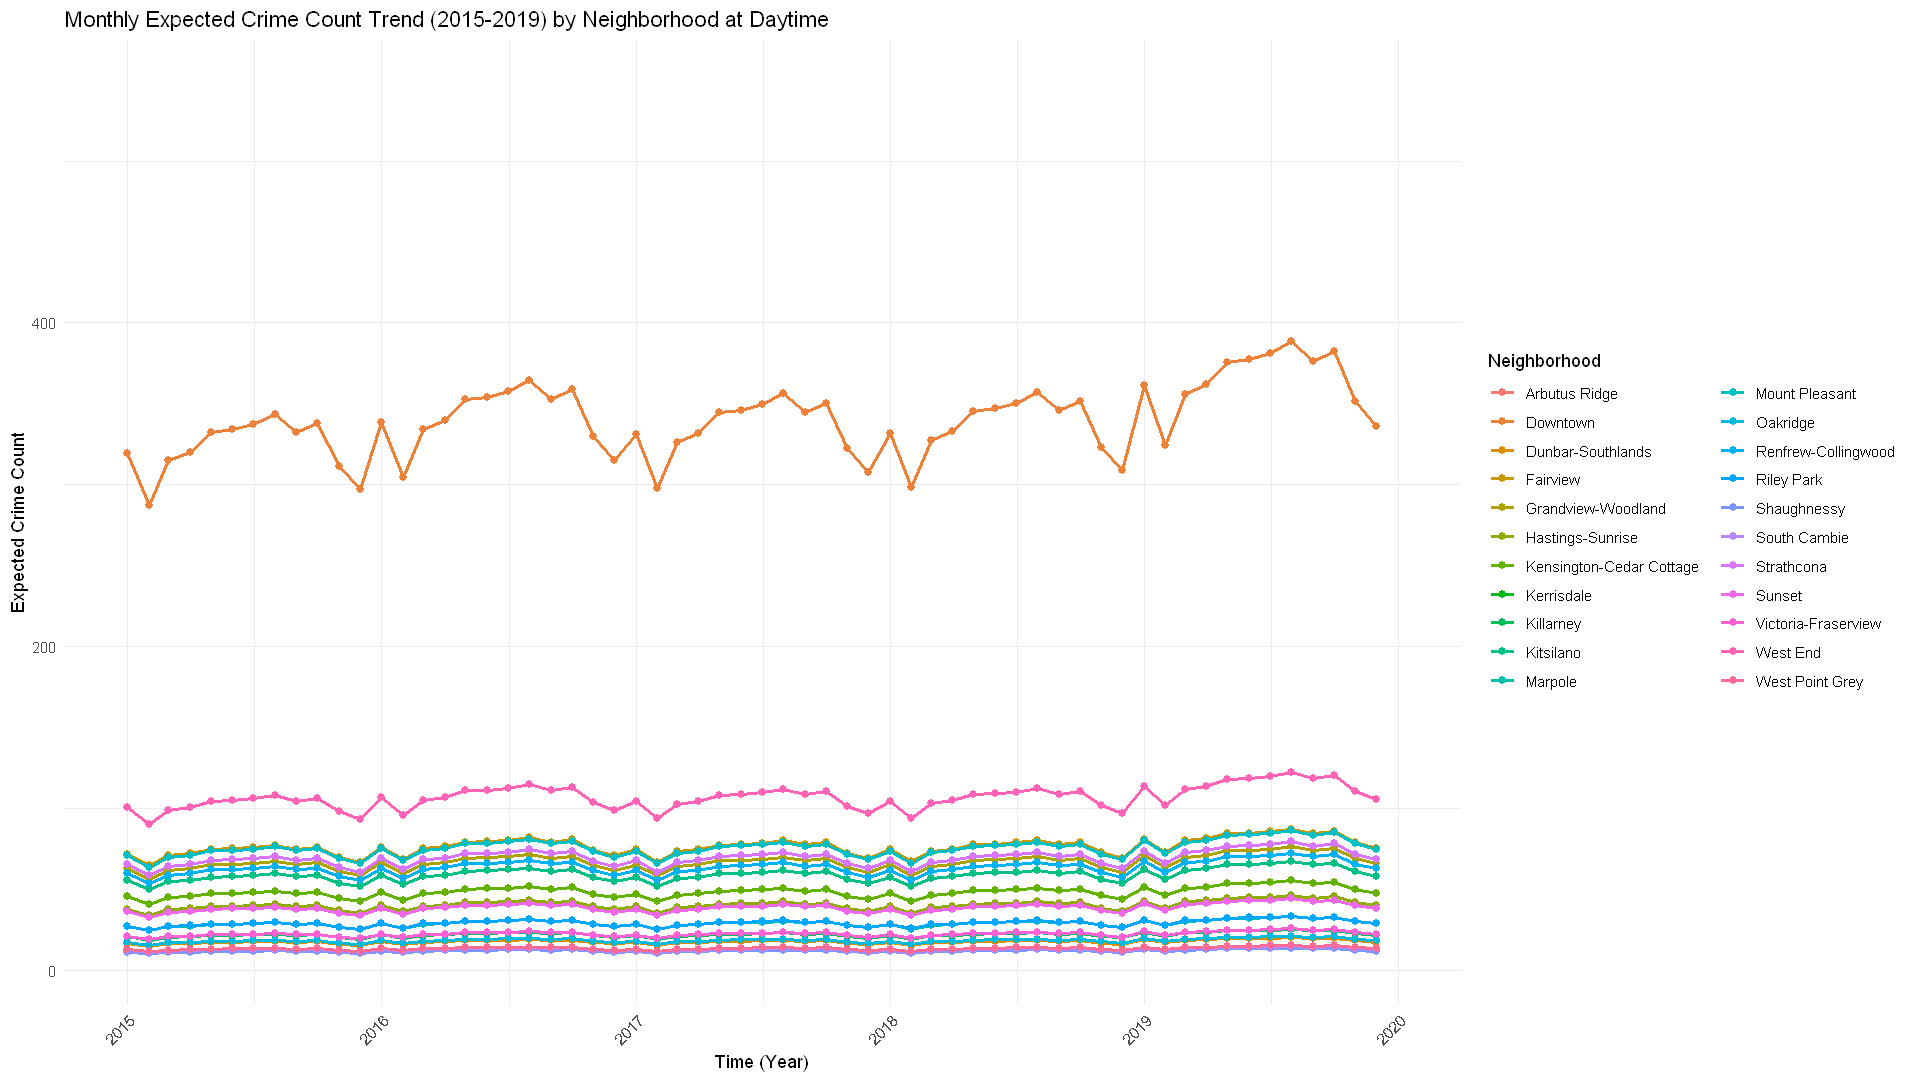

In [37]:
crime_monthly_day <- crime_monthly|>
    filter(time_category == "day")

ggplot(crime_monthly_day, aes(x = date, y = predicted_theta, color = geo_local_area, group = geo_local_area)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  # geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2015-01-01", "2019-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2015-2019) by Neighborhood at Daytime",
       color = "Neighborhood") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

Warning message:
"Removed 4554 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 4554 rows containing missing values or values outside the scale range
(`geom_point()`)."


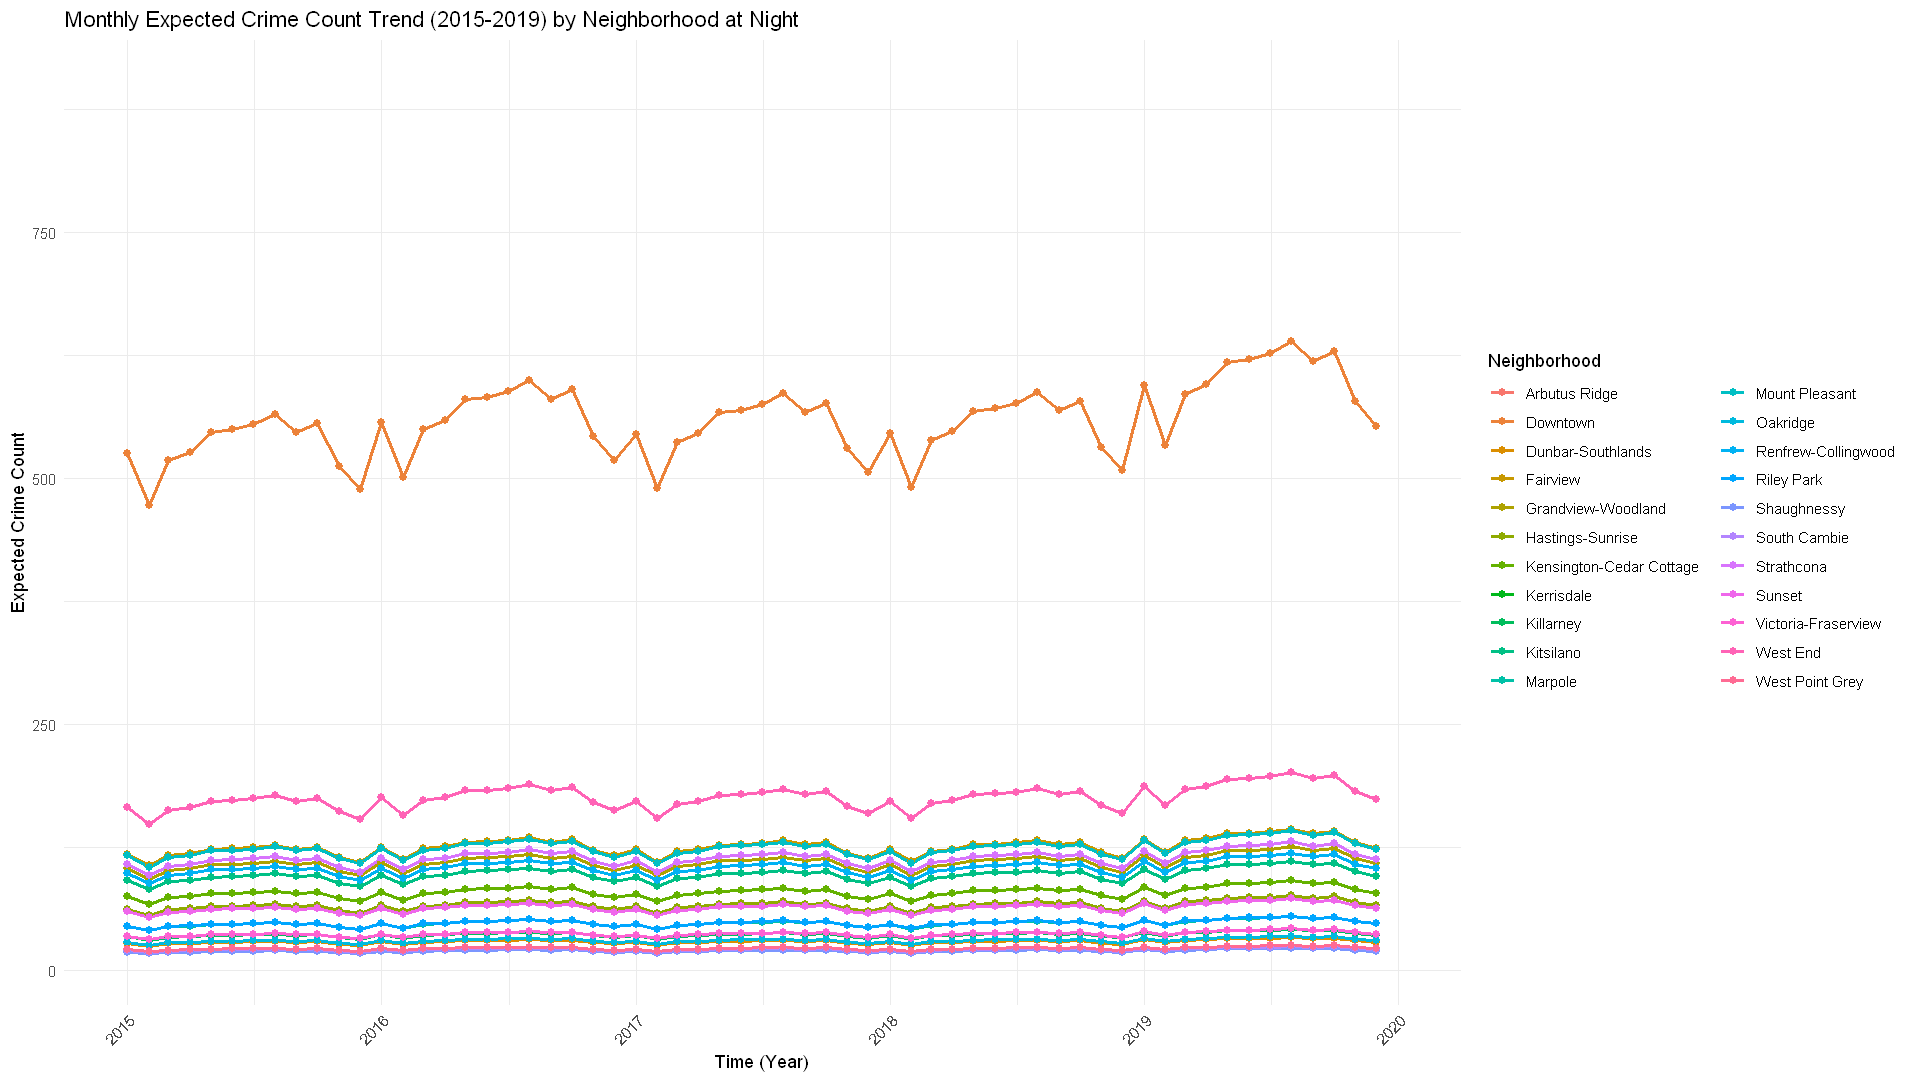

In [38]:
crime_monthly_night <- crime_monthly|>
    filter(time_category == "night")

ggplot(crime_monthly_night, aes(x = date, y = predicted_theta, color = geo_local_area, group = geo_local_area)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  # geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2015-01-01", "2019-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2015-2019) by Neighborhood at Night",
       color = "Neighborhood") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

# Panel Fixed Effect

In [39]:
install.packages("pglm")
install.packages("imputeTS")

Installing package into 'C:/Users/Kaiyan Zhang/AppData/Local/R/win-library/4.4'
(as 'lib' is unspecified)



package 'pglm' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Kaiyan Zhang\AppData\Local\Temp\Rtmpa26s0S\downloaded_packages


Installing package into 'C:/Users/Kaiyan Zhang/AppData/Local/R/win-library/4.4'
(as 'lib' is unspecified)



package 'imputeTS' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Kaiyan Zhang\AppData\Local\Temp\Rtmpa26s0S\downloaded_packages


In [40]:
# Load necessary libraries
library(dplyr)
library(lubridate)
library(plm)
library(readr)
library(pglm)
library(zoo)
library(imputeTS)

Warning message:
"package 'plm' was built under R version 4.4.3"

Attaching package: 'plm'


The following objects are masked from 'package:dplyr':

    between, lag, lead


Warning message:
"package 'pglm' was built under R version 4.4.3"
Loading required package: maxLik

Warning message:
"package 'maxLik' was built under R version 4.4.3"
Loading required package: miscTools

Warning message:
"package 'miscTools' was built under R version 4.4.3"

Please cite the 'maxLik' package as:
Henningsen, Arne and Toomet, Ott (2011). maxLik: A package for maximum likelihood estimation in R. Computational Statistics 26(3), 443-458. DOI 10.1007/s00180-010-0217-1.

If you have questions, suggestions, or comments regarding the 'maxLik' package, please use a forum or 'tracker' at maxLik's R-Forge site:
https://r-forge.r-project.org/projects/maxlik/

Warning message:
"package 'imputeTS' was built under R version 4.4.3"
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.da

In [74]:
# Read in the NTL data
ntl_data <- read_csv("NTL_data/22_ntl_2012_2024_monthly.csv")

# Optionally, rename the 'name' column to 'geo_local_area' if needed for merging
ntl_data <- ntl_data|> 
    rename(geo_local_area = name)|>
    mutate(date = as.Date(paste0(date, "-01")))|>
    mutate(
    month = month(date),
    ntl_mean_clean = if_else(month == 6, NA_real_, ntl_mean))|>
    
    glimpse()


Rows: 3432 Columns: 7


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): name, geo_point_2d, date
dbl (4): ntl_mean, n_pixels, n_non_na_pixels, prop_non_na_pixels

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3,432
Columns: 9
$ geo_local_area     <chr> "Downtown", "Hastings-Sunrise", "Kerrisdale", "Marp…
$ geo_point_2d       <chr> "{ \"lon\": -123.11656700827415, \"lat\": 49.280747…
$ ntl_mean           <dbl> 15.101049, 3.424347, 2.195419, 4.155951, 3.277409, …
$ n_pixels           <dbl> 54, 71, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 69,…
$ n_non_na_pixels    <dbl> 54, 53, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 45,…
$ prop_non_na_pixels <dbl> 1.0000000, 0.7464789, 1.0000000, 1.0000000, 1.00000…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…
$ month              <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ ntl_mean_clean     <dbl> 15.101049, 3.424347, 2.195419, 4.155951, 3.277409, …


In [75]:
# interpolate missing values
ntl_data <- ntl_data |>
  arrange(date) |>
  mutate(
    ntl_mean_imputed = na_interpolation(ntl_mean_clean, option = "linear")
  )|>
  glimpse()

Rows: 3,432
Columns: 10
$ geo_local_area     <chr> "Downtown", "Hastings-Sunrise", "Kerrisdale", "Marp…
$ geo_point_2d       <chr> "{ \"lon\": -123.11656700827415, \"lat\": 49.280747…
$ ntl_mean           <dbl> 15.101049, 3.424347, 2.195419, 4.155951, 3.277409, …
$ n_pixels           <dbl> 54, 71, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 69,…
$ n_non_na_pixels    <dbl> 54, 53, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 45,…
$ prop_non_na_pixels <dbl> 1.0000000, 0.7464789, 1.0000000, 1.0000000, 1.00000…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…
$ month              <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ ntl_mean_clean     <dbl> 15.101049, 3.424347, 2.195419, 4.155951, 3.277409, …
$ ntl_mean_imputed   <dbl> 15.101049, 3.424347, 2.195419, 4.155951, 3.277409, …


In [77]:
ntl_data <- ntl_data |>
  arrange(geo_local_area)|>
  group_by(geo_local_area)|>
  mutate(ntl_mean_pct_change = diff(ntl_mean)/ntl_mean[-nrow(ntl_data)] * 100)|>
  ungroup()|>
  filter(!is.na(ntl_mean_pct_change))
  
head(ntl_data, 12)

Warning message:
"There were 22 warnings in `mutate()`.
The first warning was:
ℹ In argument: `ntl_mean_pct_change = diff(ntl_mean)/ntl_mean[-nrow(ntl_data)]
  * 100`.
ℹ In group 1: `geo_local_area = "Arbutus Ridge"`.
Caused by warning in `diff(ntl_mean) / ntl_mean[-nrow(ntl_data)]`:
! longer object length is not a multiple of shorter object length
ℹ Run `dplyr::last_dplyr_warnings()` to see the 21 remaining warnings."


geo_local_area,geo_point_2d,ntl_mean,n_pixels,n_non_na_pixels,prop_non_na_pixels,date,month,ntl_mean_clean,ntl_mean_imputed,ntl_mean_pct_change
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<date>,<dbl>,<dbl>,<dbl>,<dbl>
Arbutus Ridge,"{ ""lon"": -123.16166923820482, ""lat"": 49.246804909827887 }",2.994383,37,37,1,2012-01-01,1,2.994383,2.994383,8.31739634
Arbutus Ridge,"{ ""lon"": -123.16166923820482, ""lat"": 49.246804909827887 }",3.243437,37,37,1,2012-02-01,2,3.243437,3.243437,22.00833845
Arbutus Ridge,"{ ""lon"": -123.16166923820482, ""lat"": 49.246804909827887 }",3.957264,37,37,1,2012-03-01,3,3.957264,3.957264,-17.58902656
Arbutus Ridge,"{ ""lon"": -123.16166923820482, ""lat"": 49.246804909827887 }",3.261220,37,37,1,2012-04-01,4,3.261220,3.261220,-1.03244153
Arbutus Ridge,"{ ""lon"": -123.16166923820482, ""lat"": 49.246804909827887 }",3.104404,37,37,1,2012-07-01,7,3.104404,3.104404,0.04194823
Arbutus Ridge,"{ ""lon"": -123.16166923820482, ""lat"": 49.246804909827887 }",3.105706,37,37,1,2012-08-01,8,3.105706,3.105706,5.36566286
Arbutus Ridge,"{ ""lon"": -123.16166923820482, ""lat"": 49.246804909827887 }",3.272348,37,37,1,2012-09-01,9,3.272348,3.272348,-6.75278744
Arbutus Ridge,"{ ""lon"": -123.16166923820482, ""lat"": 49.246804909827887 }",3.051373,37,37,1,2012-10-01,10,3.051373,3.051373,-14.50378977
Arbutus Ridge,"{ ""lon"": -123.16166923820482, ""lat"": 49.246804909827887 }",2.608808,37,37,1,2012-11-01,11,2.608808,2.608808,8.79996454


Warning message:
"Removed 220 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 220 rows containing missing values or values outside the scale range
(`geom_point()`)."


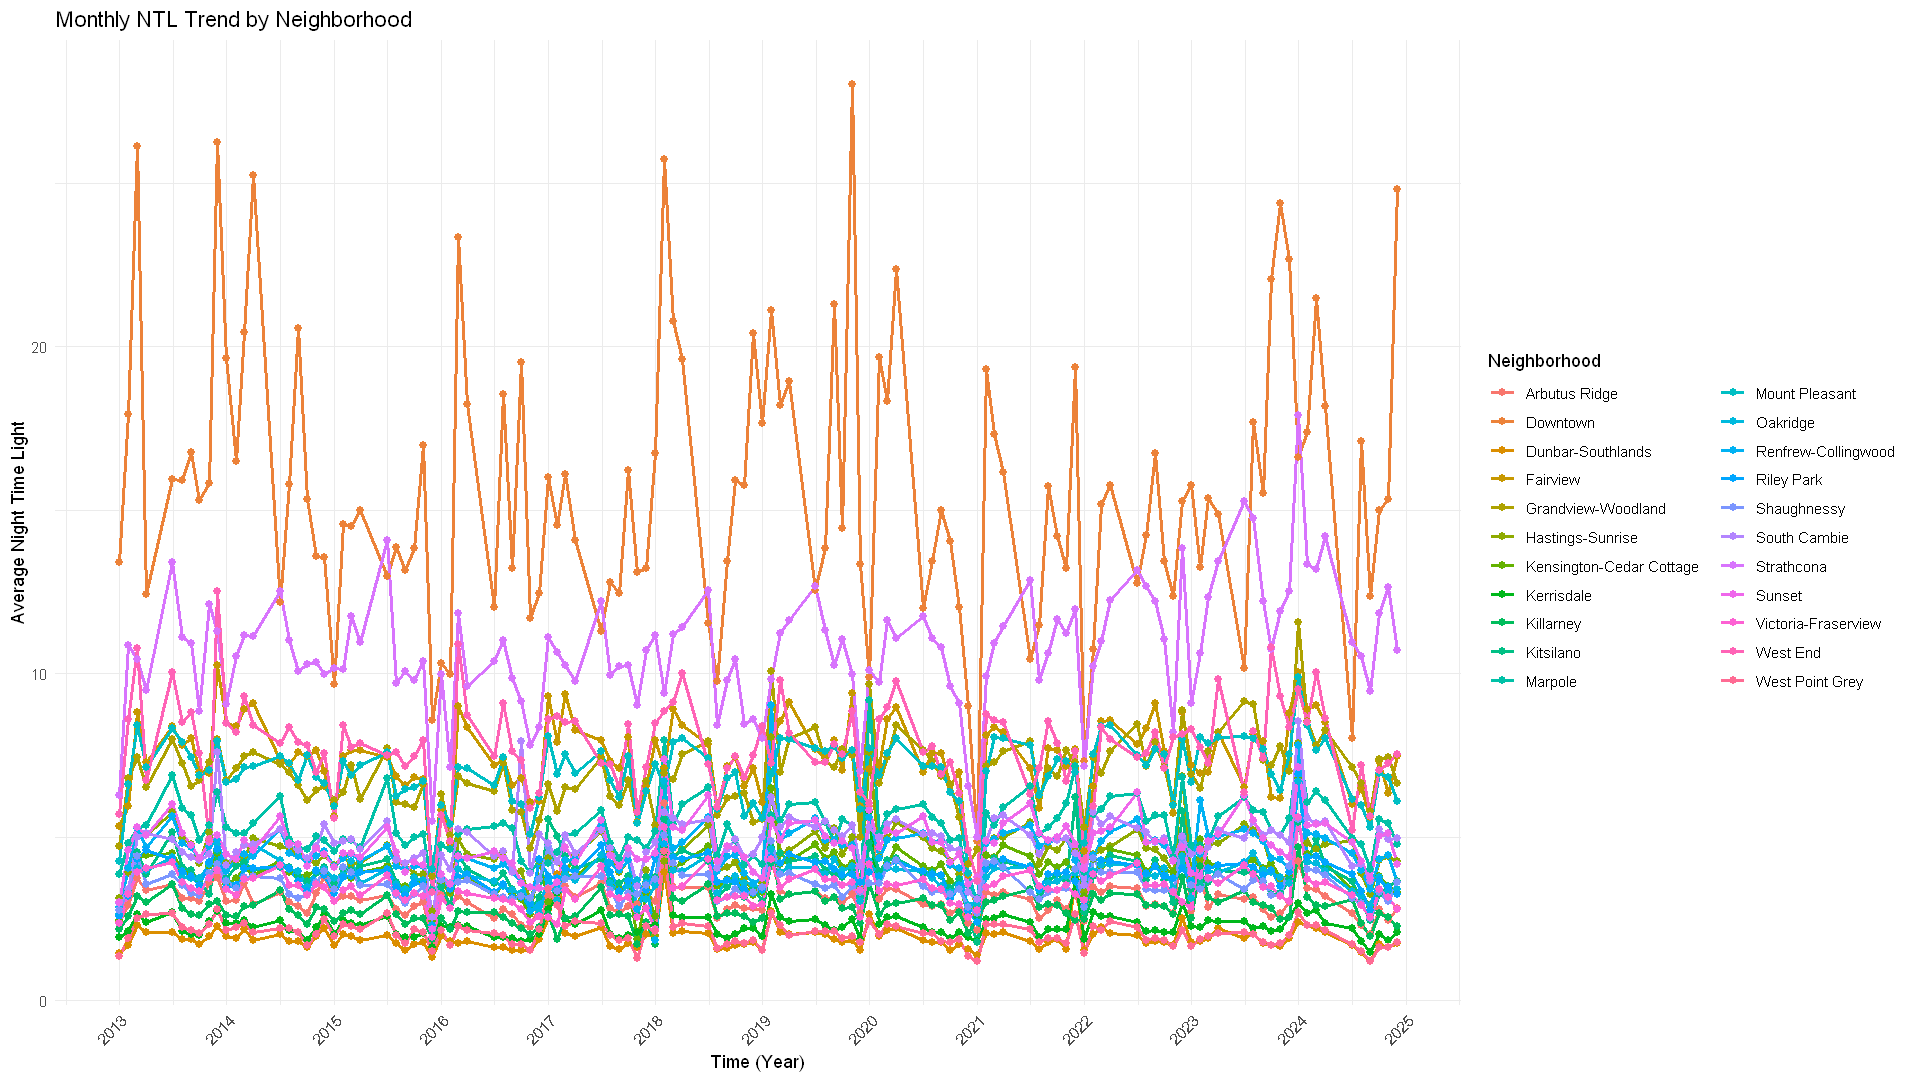

In [78]:
ggplot(ntl_data, aes(x = date, y = ntl_mean, color = geo_local_area, group =geo_local_area)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
#   geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "202501-01"))) +
  labs(x = "Time (Year)", y = "Average Night Time Light", 
       title = "Monthly NTL Trend by Neighborhood",
       color = "Neighborhood") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [84]:
ntl_fixed_effect <- ntl_data|>
    mutate(policy = ifelse(date >= "2019-11-01", 1, 0))|>
    mutate(month = as.factor(month))|>
    mutate(year = as.factor(year(date)))|>
    glimpse()

ntl_model <- lm(ntl_mean_pct_change ~ year + month, data = ntl_fixed_effect)

summary(ntl_model)

Rows: 2,860
Columns: 13
$ geo_local_area      <chr> "Arbutus Ridge", "Arbutus Ridge", "Arbutus Ridge",…
$ geo_point_2d        <chr> "{ \"lon\": -123.16166923820482, \"lat\": 49.24680…
$ ntl_mean            <dbl> 2.994383, 3.243437, 3.957264, 3.261220, 3.104404, …
$ n_pixels            <dbl> 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37…
$ n_non_na_pixels     <dbl> 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37…
$ prop_non_na_pixels  <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ date                <date> 2012-01-01, 2012-02-01, 2012-03-01, 2012-04-01, 2…
$ month               <fct> 1, 2, 3, 4, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 7, 8,…
$ ntl_mean_clean      <dbl> 2.994383, 3.243437, 3.957264, 3.261220, 3.104404, …
$ ntl_mean_imputed    <dbl> 2.994383, 3.243437, 3.957264, 3.261220, 3.104404, …
$ ntl_mean_pct_change <dbl> 8.31739634, 22.00833845, -17.58902656, -1.03244153…
$ policy              <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ year          


Call:
lm(formula = ntl_mean_pct_change ~ year + month, data = ntl_fixed_effect)

Residuals:
    Min      1Q  Median      3Q     Max 
-73.046 -10.836  -1.673   8.084 271.467 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  17.8595     2.0760   8.603  < 2e-16 ***
year2013      5.9862     2.2568   2.652 0.008035 ** 
year2014      0.4834     2.2568   0.214 0.830404    
year2015      3.3295     2.2568   1.475 0.140250    
year2016      4.5660     2.2568   2.023 0.043147 *  
year2017     -0.2602     2.2568  -0.115 0.908222    
year2018      3.1639     2.2568   1.402 0.161048    
year2019      7.9378     2.2568   3.517 0.000443 ***
year2020     -4.4747     2.2568  -1.983 0.047495 *  
year2021      7.7172     2.2568   3.419 0.000636 ***
year2022      4.9284     2.2568   2.184 0.029062 *  
year2023      8.7047     2.2568   3.857 0.000117 ***
year2024      1.2533     2.2568   0.555 0.578724    
month2      -15.2522     1.9794  -7.706 1.79e-14 ***
month3      -21

Warning message:
"Removed 12 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 24 rows containing missing values or values outside the scale range
(`geom_point()`)."


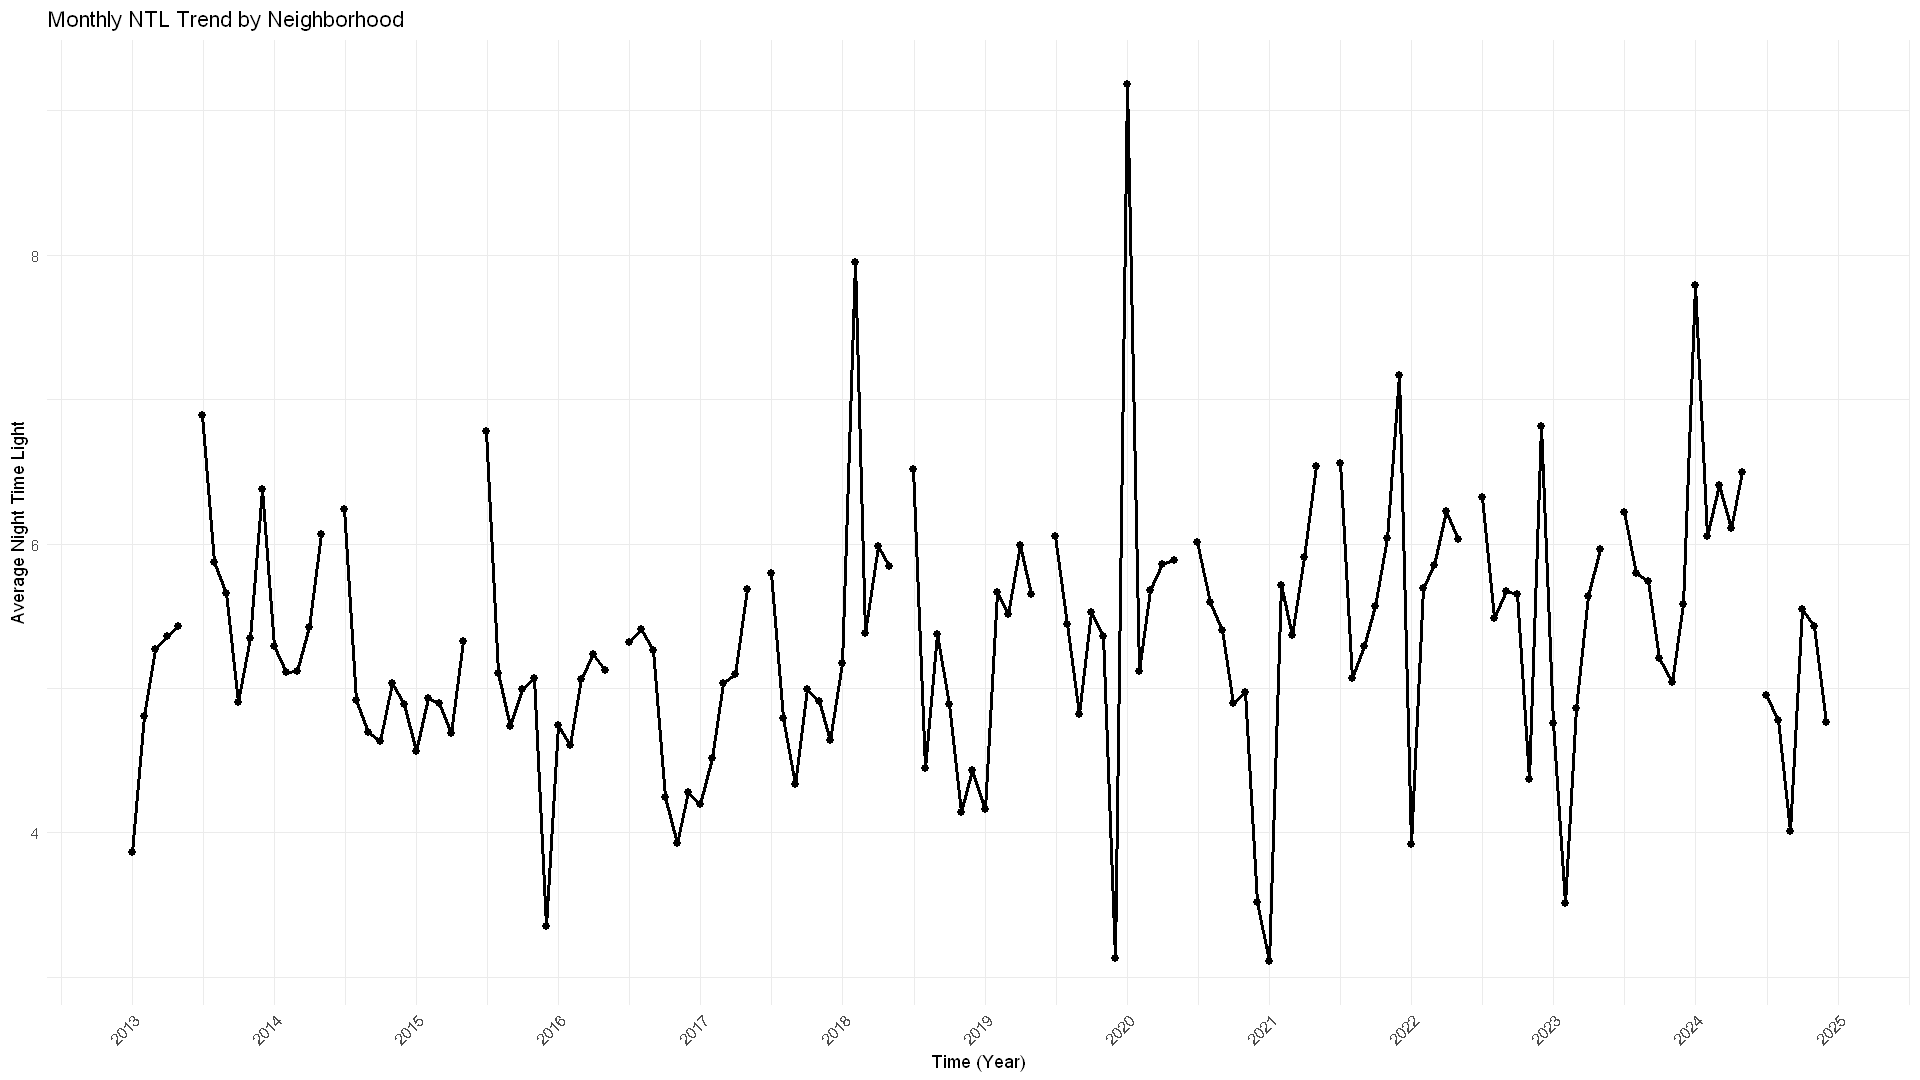

In [61]:
ntl_data_marpole <- ntl_data|>
    filter(geo_local_area == "Marpole")

ggplot(ntl_data_marpole, aes(x = date, y = ntl_mean)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
#   geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "202501-01"))) +
  labs(x = "Time (Year)", y = "Average Night Time Light", 
       title = "Monthly NTL Trend by Neighborhood") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [44]:
# Merge the crime summary with the NTL data (assuming NTL data's date column is in "YYYY-MM" format)
data_merged <- merge(crime_monthly_night, ntl_data, by.x = c("geo_local_area", "date"), by.y = c("geo_local_area", "date"))|>
    filter(2015 <= year(date) & year(date) <= 2018)

# Check the merged data
head(data_merged)


,geo_local_area,date,year,month.x,time_category,crime_count,predicted_lambda,predicted_theta,geo_point_2d,ntl_mean,n_pixels,n_non_na_pixels,prop_non_na_pixels,month.y,ntl_mean_clean,ntl_mean_imputed
,<fct>,<date>,<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Arbutus Ridge,2015-01-01,2015,1,night,25,20.36327,20.55587,"{ ""lon"": -123.16166923820482, ""lat"": 49.246804909827887 }",3.031333,37,37,1,1,3.031333,3.031333
2,Arbutus Ridge,2015-02-01,2015,2,night,18,18.49259,18.46994,"{ ""lon"": -123.16166923820482, ""lat"": 49.246804909827887 }",3.172477,37,37,1,2,3.172477,3.172477
3,Arbutus Ridge,2015-03-01,2015,3,night,17,20.10531,20.27075,"{ ""lon"": -123.16166923820482, ""lat"": 49.246804909827887 }",3.181031,37,37,1,3,3.181031,3.181031
4,Arbutus Ridge,2015-04-01,2015,4,night,15,19.75130,20.61192,"{ ""lon"": -123.16166923820482, ""lat"": 49.246804909827887 }",3.070141,37,37,1,4,3.070141,3.070141
5,Arbutus Ridge,2015-05-01,2015,5,night,19,20.62494,21.39407,"{ ""lon"": -123.16166923820482, ""lat"": 49.246804909827887 }",3.120766,37,37,1,5,3.120766,3.120766
6,Arbutus Ridge,2015-06-01,2015,6,night,12,20.66680,21.49066,"{ ""lon"": -123.16166923820482, ""lat"": 49.246804909827887 }",NA,37,0,0,6,NA,9.263045


In [45]:

# Run a fixed effects panel model (linear regression with entity FE)
model_fe <- plm(predicted_theta ~ ntl_mean_imputed + year(date) + month(date), 
                data = data_merged, 
                model = "within",  # Within estimator = Fixed Effects
                index = c("geo_local_area", "date"))

# Summarize the model results
summary(model_fe)

Warning message:
"tz(): Don't know how to compute timezone for object of class pseries/factor; returning "UTC"."
Warning message:
"tz(): Don't know how to compute timezone for object of class pseries/factor; returning "UTC"."


Oneway (individual) effect Within Model

Call:
plm(formula = predicted_theta ~ ntl_mean_imputed + year(date) + 
    month(date), data = data_merged, model = "within", index = c("geo_local_area", 
    "date"))

Balanced Panel: n = 22, T = 48, N = 1056

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-73.93028  -1.82276   0.55921   2.19091  51.85181 

Coefficients:
                  Estimate Std. Error t-value  Pr(>|t|)    
ntl_mean_imputed -0.111980   0.146502 -0.7644 0.4448271    
year(date)        0.798651   0.215988  3.6977 0.0002291 ***
month(date)       0.210484   0.070845  2.9711 0.0030365 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Total Sum of Squares:    64446
Residual Sum of Squares: 62989
R-Squared:      0.022618
Adj. R-Squared: -0.00013403
F-statistic: 7.95287 on 3 and 1031 DF, p-value: 3.0301e-05

Warning message:
"Removed 286 rows containing missing values or values outside the scale range
(`geom_point()`)."


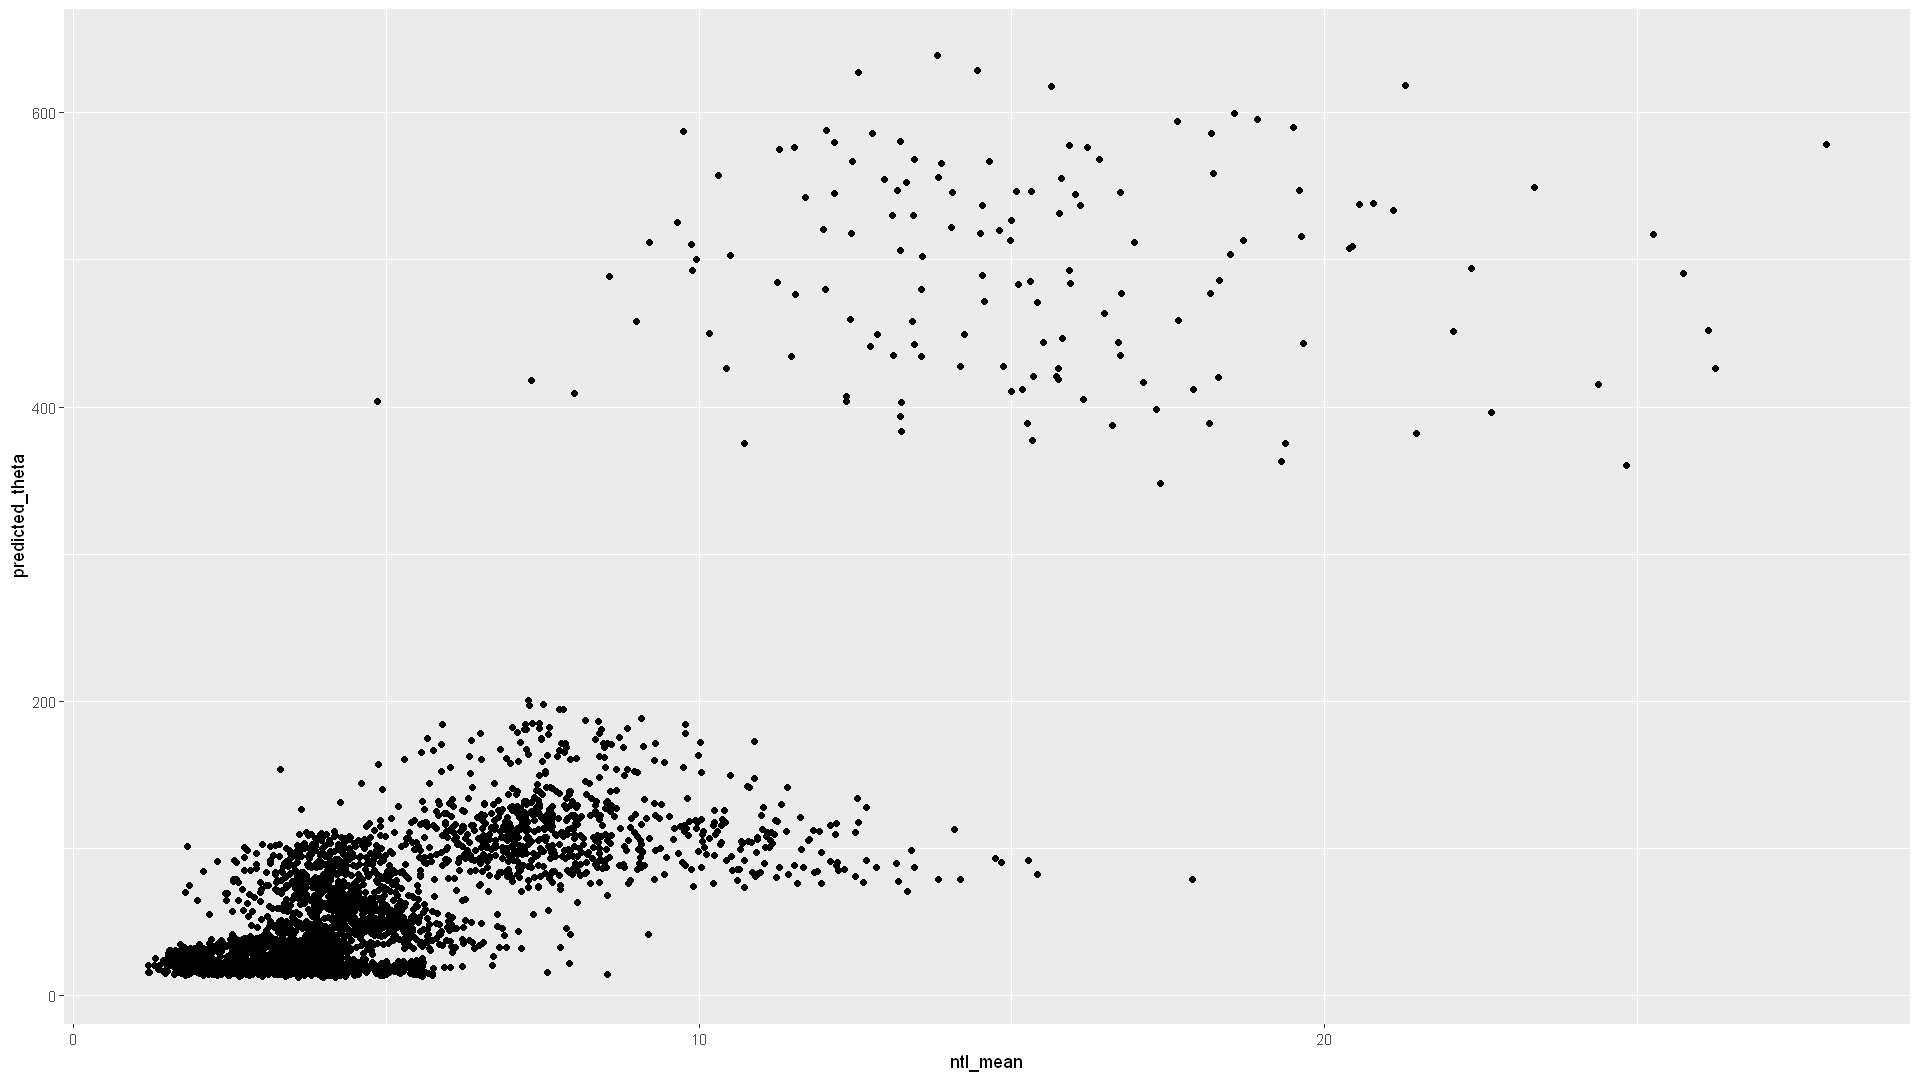

In [58]:
ggplot(data_merged, aes(x = ntl_mean, y = predicted_theta)) +
    geom_point()

# DID

Warning message:
"Removed 12 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 24 rows containing missing values or values outside the scale range
(`geom_point()`)."


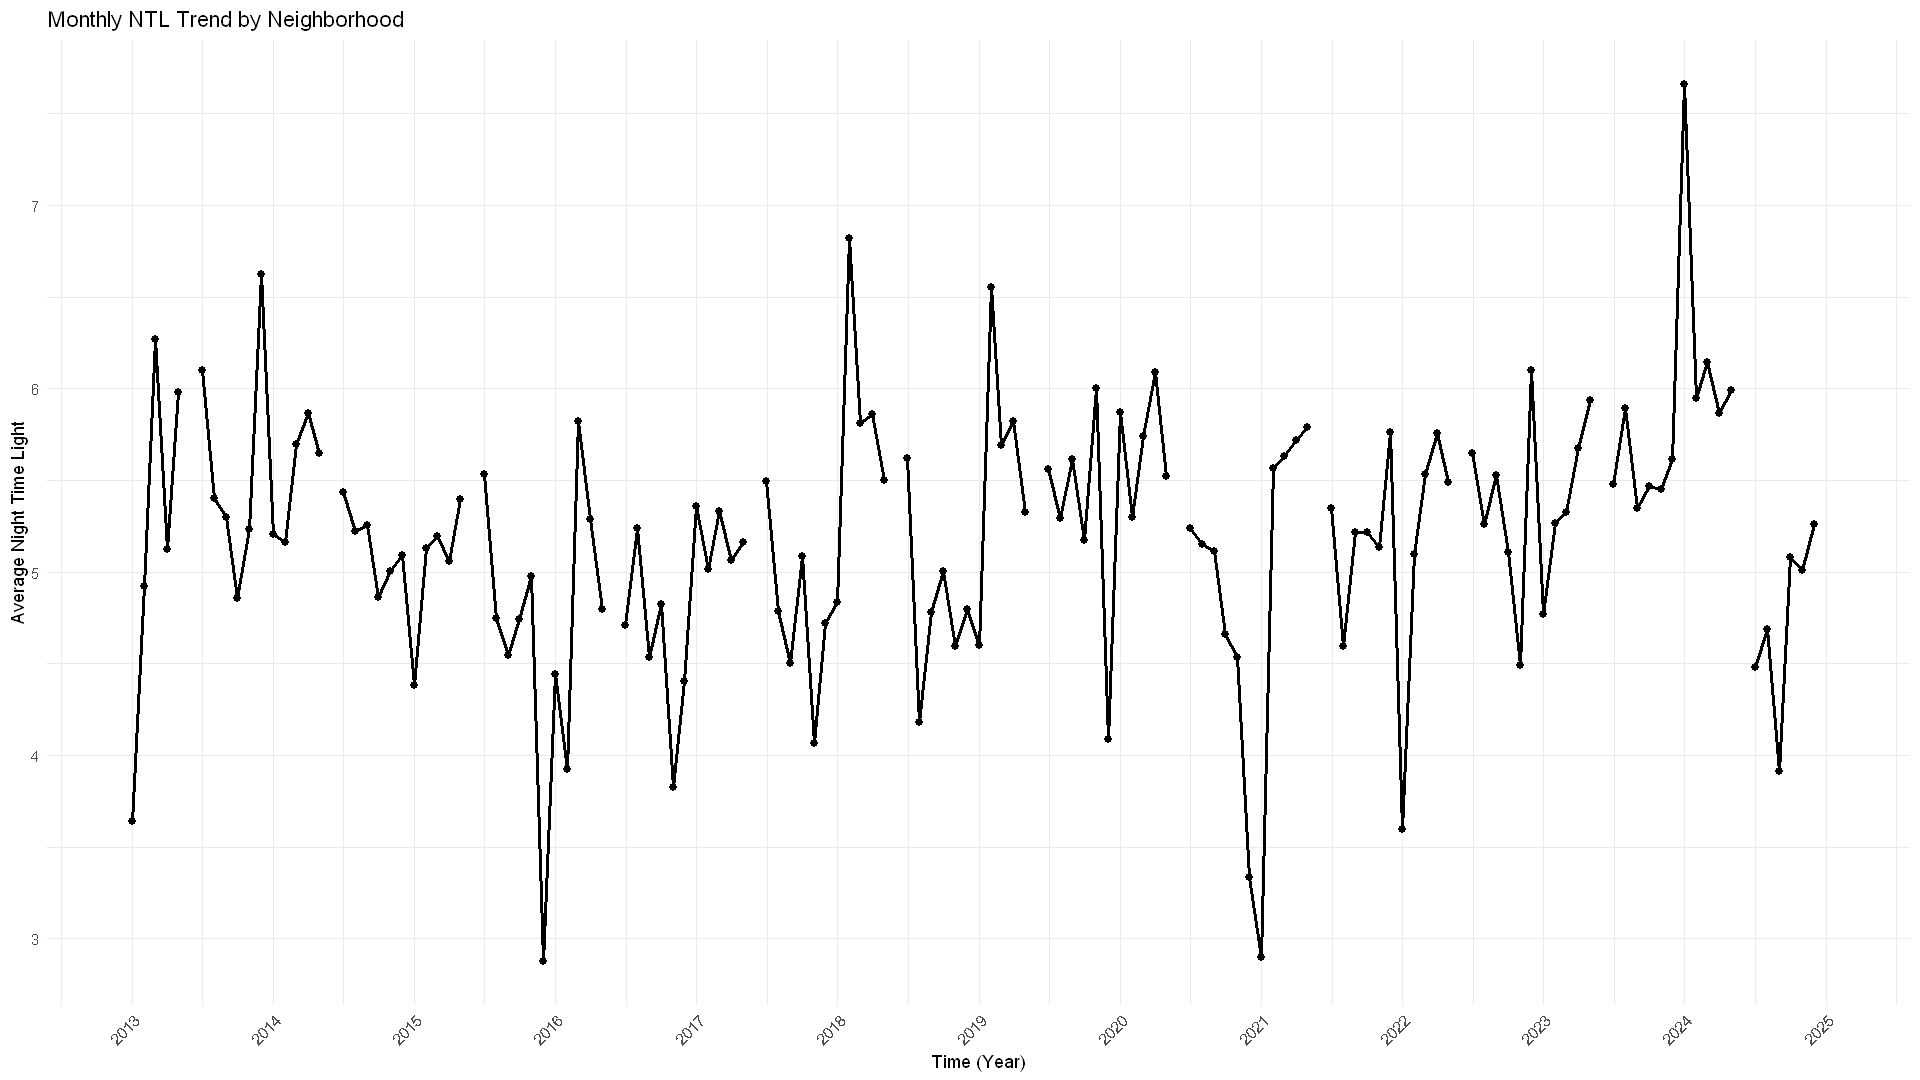

In [56]:
ntl_trend <- ntl_data|>
    group_by(date)|>
    summarise(ntl_mean = mean(ntl_mean))


ggplot(ntl_trend, aes(x = date, y = ntl_mean)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
#   geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2025-01-01"))) +
  labs(x = "Time (Year)", y = "Average Night Time Light", 
       title = "Monthly NTL Trend by Neighborhood") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [47]:
merged_data_did <- merge(crime_monthly, ntl_data, by.x = c("geo_local_area", "date"), by.y = c("geo_local_area", "date"))|>
    filter(date >= "2016-11-01" & date <= "2017-06-01")|>
    mutate(post = ifelse((date >= "2016-12-01"),1,0))|>
    mutate(treatment = ifelse(time_category == "night", 1, 0))|>
    glimpse()

Rows: 352
Columns: 18
$ geo_local_area     <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ date               <date> 2016-11-01, 2016-11-01, 2016-12-01, 2016-12-01, 20…
$ year               <fct> 2016, 2016, 2016, 2016, 2017, 2017, 2017, 2017, 201…
$ month.x            <fct> 11, 11, 12, 12, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6,…
$ time_category      <fct> day, night, day, night, day, night, day, night, day…
$ crime_count        <int> 8, 21, 11, 25, 5, 16, 8, 27, 9, 27, 30, 11, 20, 18,…
$ predicted_lambda   <dbl> 14.13472, 21.97020, 13.73251, 21.34504, 14.29924, 2…
$ predicted_theta    <dbl> 12.91181, 21.23889, 12.32515, 20.27388, 12.95264, 2…
$ geo_point_2d       <chr> "{ \"lon\": -123.16166923820482, \"lat\": 49.246804…
$ ntl_mean           <dbl> 2.242166, 2.242166, 2.918018, 2.918018, 3.183501, 3…
$ n_pixels           <dbl> 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37,…
$ n_non_na_pixels    <dbl> 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37,…
$ prop_non_na_pixe

`summarise()` has grouped output by 'date'. You can override using the
`.groups` argument.


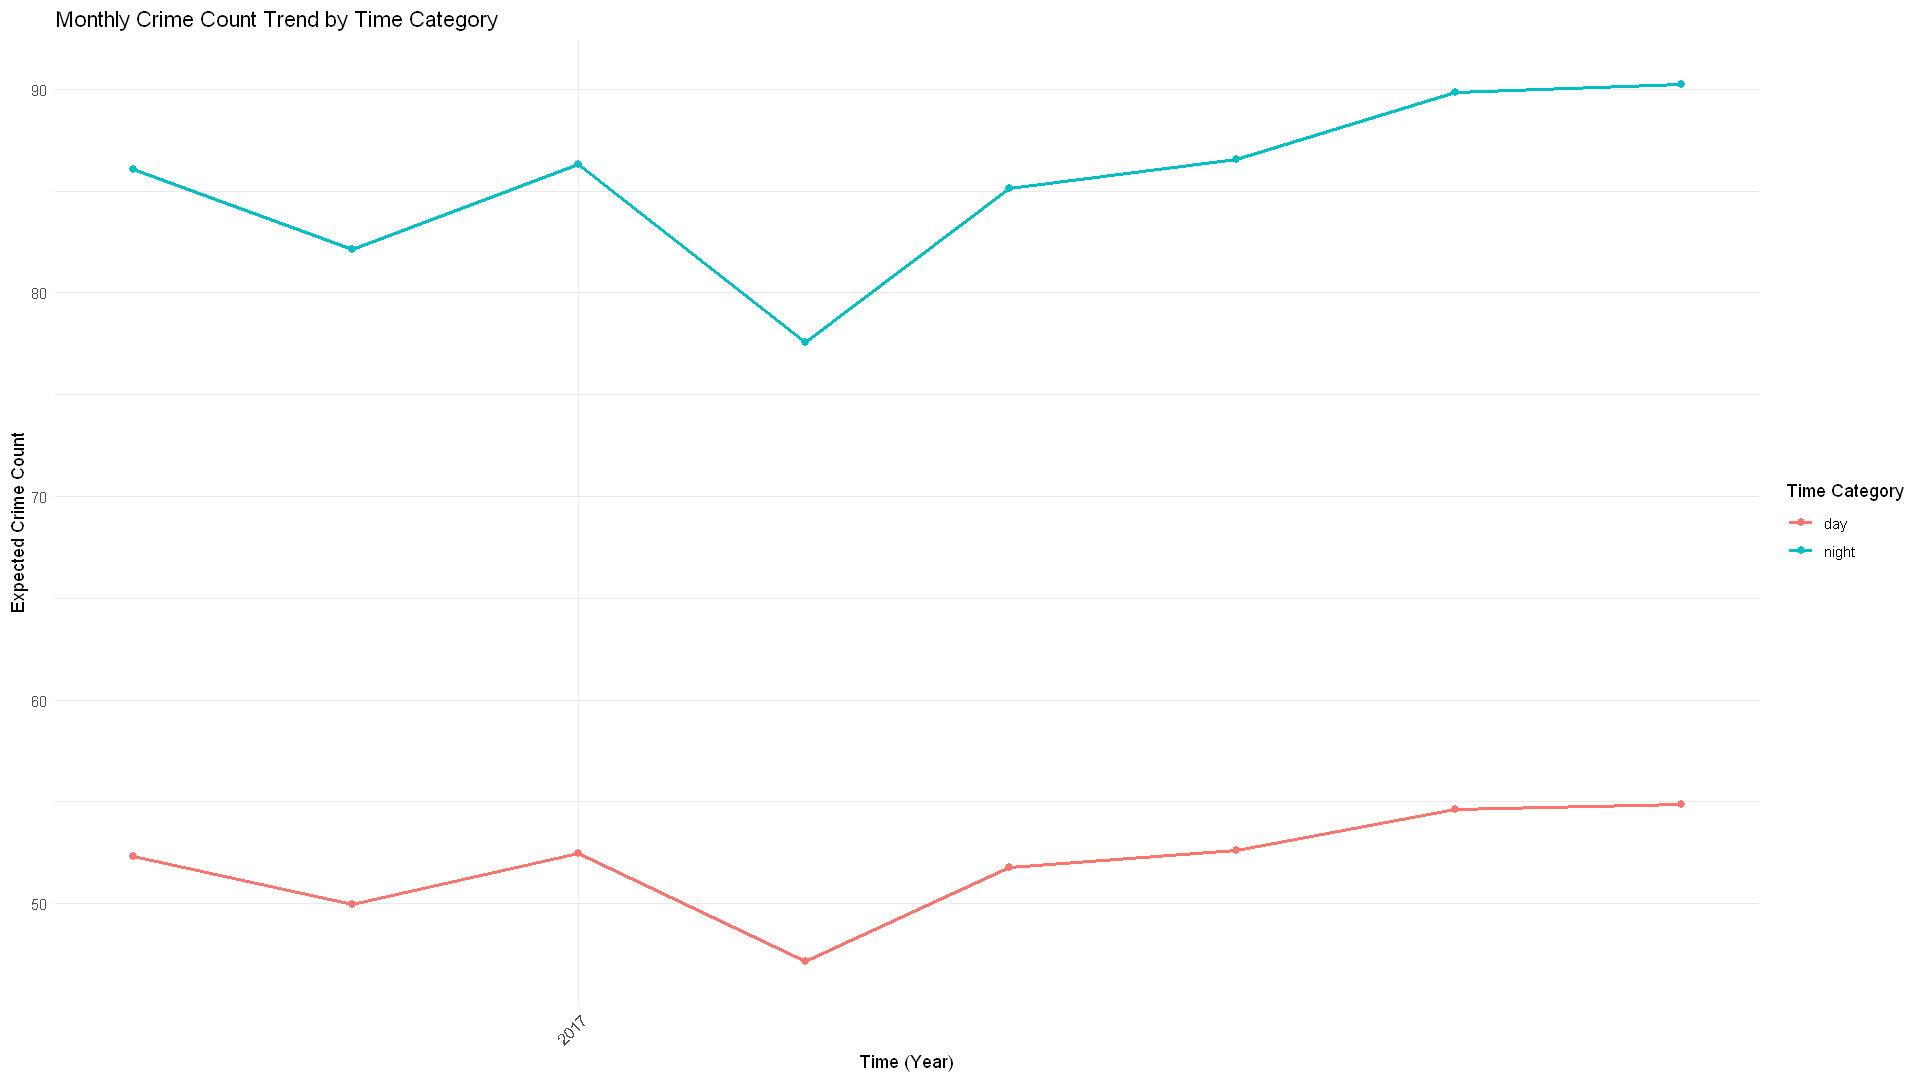

In [48]:
crime_trend <- merged_data_did|>
    group_by(date, time_category)|>
    summarise(predicted_theta = mean(predicted_theta))

ggplot(crime_trend, aes(x = date, y = predicted_theta, color = time_category, group = time_category)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
#   geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2016-11-01", "2017-06-01"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Crime Count Trend by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [49]:
model_did_2016 <- lm(predicted_theta ~  post * treatment, data = merged_data_did)

summary(model_did_2016)


Call:
lm(formula = predicted_theta ~ post * treatment, data = merged_data_did)

Residuals:
   Min     1Q Median     3Q    Max 
-68.30 -39.96 -23.69  14.86 483.73 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)   
(Intercept)     52.3176    19.0815   2.742  0.00643 **
post            -0.3954    20.3990  -0.019  0.98454   
treatment       33.7407    26.9854   1.250  0.21202   
post:treatment  -0.2550    28.8486  -0.009  0.99295   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 89.5 on 348 degrees of freedom
Multiple R-squared:  0.03425,	Adjusted R-squared:  0.02593 
F-statistic: 4.114 on 3 and 348 DF,  p-value: 0.006897


   start_year end_year        coef        se
1        2012     2013 -1.81862463 0.2200715
2        2012     2014 -0.75060542 0.2453907
3        2012     2015 -1.08638176 0.2291645
4        2012     2016 -0.67474976 0.2384343
5        2012     2017 -0.87032056 0.2274279
6        2012     2018 -0.96173745 0.2013932
7        2012     2019 -0.38243684 0.2076179
8        2012     2020 -0.27119237 0.1912636
9        2012     2021  0.01982690 0.2179263
10       2012     2022  0.62644593 0.2224300
11       2012     2023  0.13324584 0.2151007
12       2012     2024 -0.20516632 0.2131838
13       2013     2014 -1.18604115 0.3543330
14       2013     2015 -1.76180268 0.2821474
15       2013     2016 -1.30895312 0.2747003
16       2013     2017 -1.52269345 0.2510753
17       2013     2018 -1.59844454 0.2145158
18       2013     2019 -0.98935666 0.2185110
19       2013     2020 -0.70567702 0.2018981
20       2013     2021 -0.18938405 0.2367041
21       2013     2022  0.58303044 0.2415408
22       2

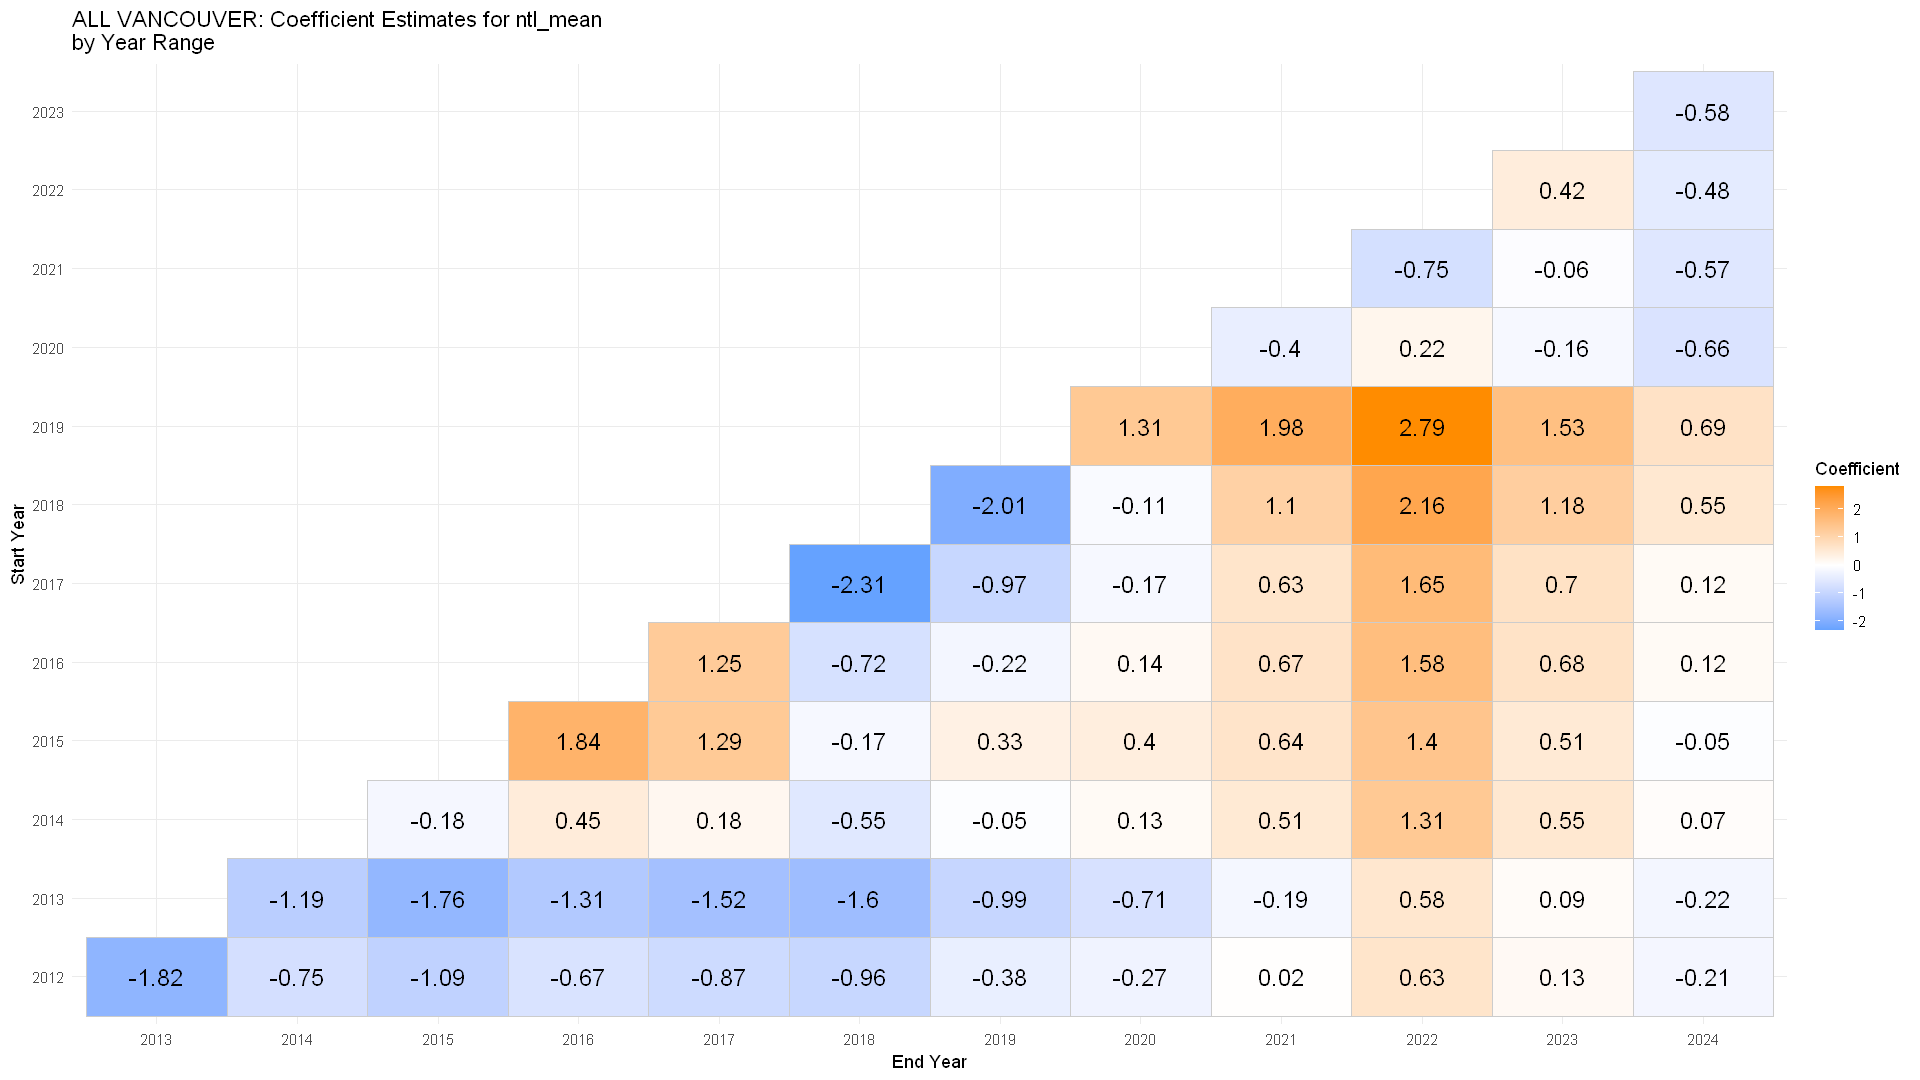

In [50]:
# Load necessary libraries
library(dplyr)
library(lubridate)
library(plm)
library(ggplot2)

# Define the range of years for the analysis.
# For a 10x10 grid you could use: years <- 2012:2021
# Here we use 2012:2014 as an example:
years <- 2012:2024
data_merged <- merge(crime_monthly_night, ntl_data, by.x = c("geo_local_area", "date"), by.y = c("geo_local_area", "date"))

# 在合并后的数据中增加 year 和 month 变量
data_merged <- data_merged %>% 
  mutate(year = year(date),
         month = month(date))


coef_results <- data.frame(start_year = integer(),
                           end_year = integer(),
                           coef = numeric(),
                           se = numeric())

# Loop over all valid start-end combinations (end > start)
for(start in years) {
  for(end in years) {
    if(end > start) {  # 确保有效区间
      # Subset data_merged，且自动带入 year 和 month
      data_subset <- data_merged %>% 
        filter(year >= start & year <= end)
      
      # 检查样本量是否足够
      if(nrow(data_subset) < 10) next
      
      # 使用 plm 进行固定效应回归，同时控制年和月固定效应
      model <- plm(predicted_theta ~ ntl_mean + factor(year) + factor(month),
                   data = data_subset, 
                   model = "within", 
                   index = c("geo_local_area", "date"))
      
      # 提取 ntl_mean 的系数及标准误
      coef_est <- coef(summary(model))["ntl_mean", "Estimate"]
      se_est   <- coef(summary(model))["ntl_mean", "Std. Error"]
      
      # 将结果追加到结果数据框中
      coef_results <- rbind(coef_results,
                            data.frame(start_year = start, end_year = end,
                                       coef = coef_est, se = se_est))
    }
  }
}


# Print the coefficient results table
print(coef_results)

ggplot(coef_results, aes(x = factor(end_year), y = factor(start_year), fill = coef)) +
  geom_tile(color = "grey80") +
  geom_text(aes(label = round(coef, 2)), color = "black", size = 5) +
  labs(x = "End Year", 
       y = "Start Year", 
       title = "ALL VANCOUVER: Coefficient Estimates for ntl_mean\nby Year Range",
       fill = "Coefficient") +
  theme_minimal() +
  scale_fill_gradient2(low = "dodgerblue", mid = "white", high = "darkorange", midpoint = 0)



   start_year end_year        coef        se
1        2012     2013 -1.47723342 0.5562870
2        2012     2014 -0.67048337 0.5521842
3        2012     2015 -1.04449679 0.5050271
4        2012     2016 -0.70750352 0.5256832
5        2012     2017 -0.91578391 0.5019029
6        2012     2018 -1.04454028 0.4422239
7        2012     2019 -0.58130372 0.4560394
8        2012     2020 -0.55874822 0.4265587
9        2012     2021 -0.26942921 0.4890663
10       2012     2022  0.29902606 0.5015643
11       2012     2023  0.15397859 0.4809377
12       2012     2024  0.17103072 0.4825206
13       2013     2014 -0.96065805 0.7999147
14       2013     2015 -1.51983708 0.6316443
15       2013     2016 -1.14636008 0.6231842
16       2013     2017 -1.36345207 0.5685641
17       2013     2018 -1.50732637 0.4810521
18       2013     2019 -0.98235856 0.4859734
19       2013     2020 -0.87849256 0.4579528
20       2013     2021 -0.42091185 0.5408455
21       2013     2022  0.29540495 0.5539097
22       2

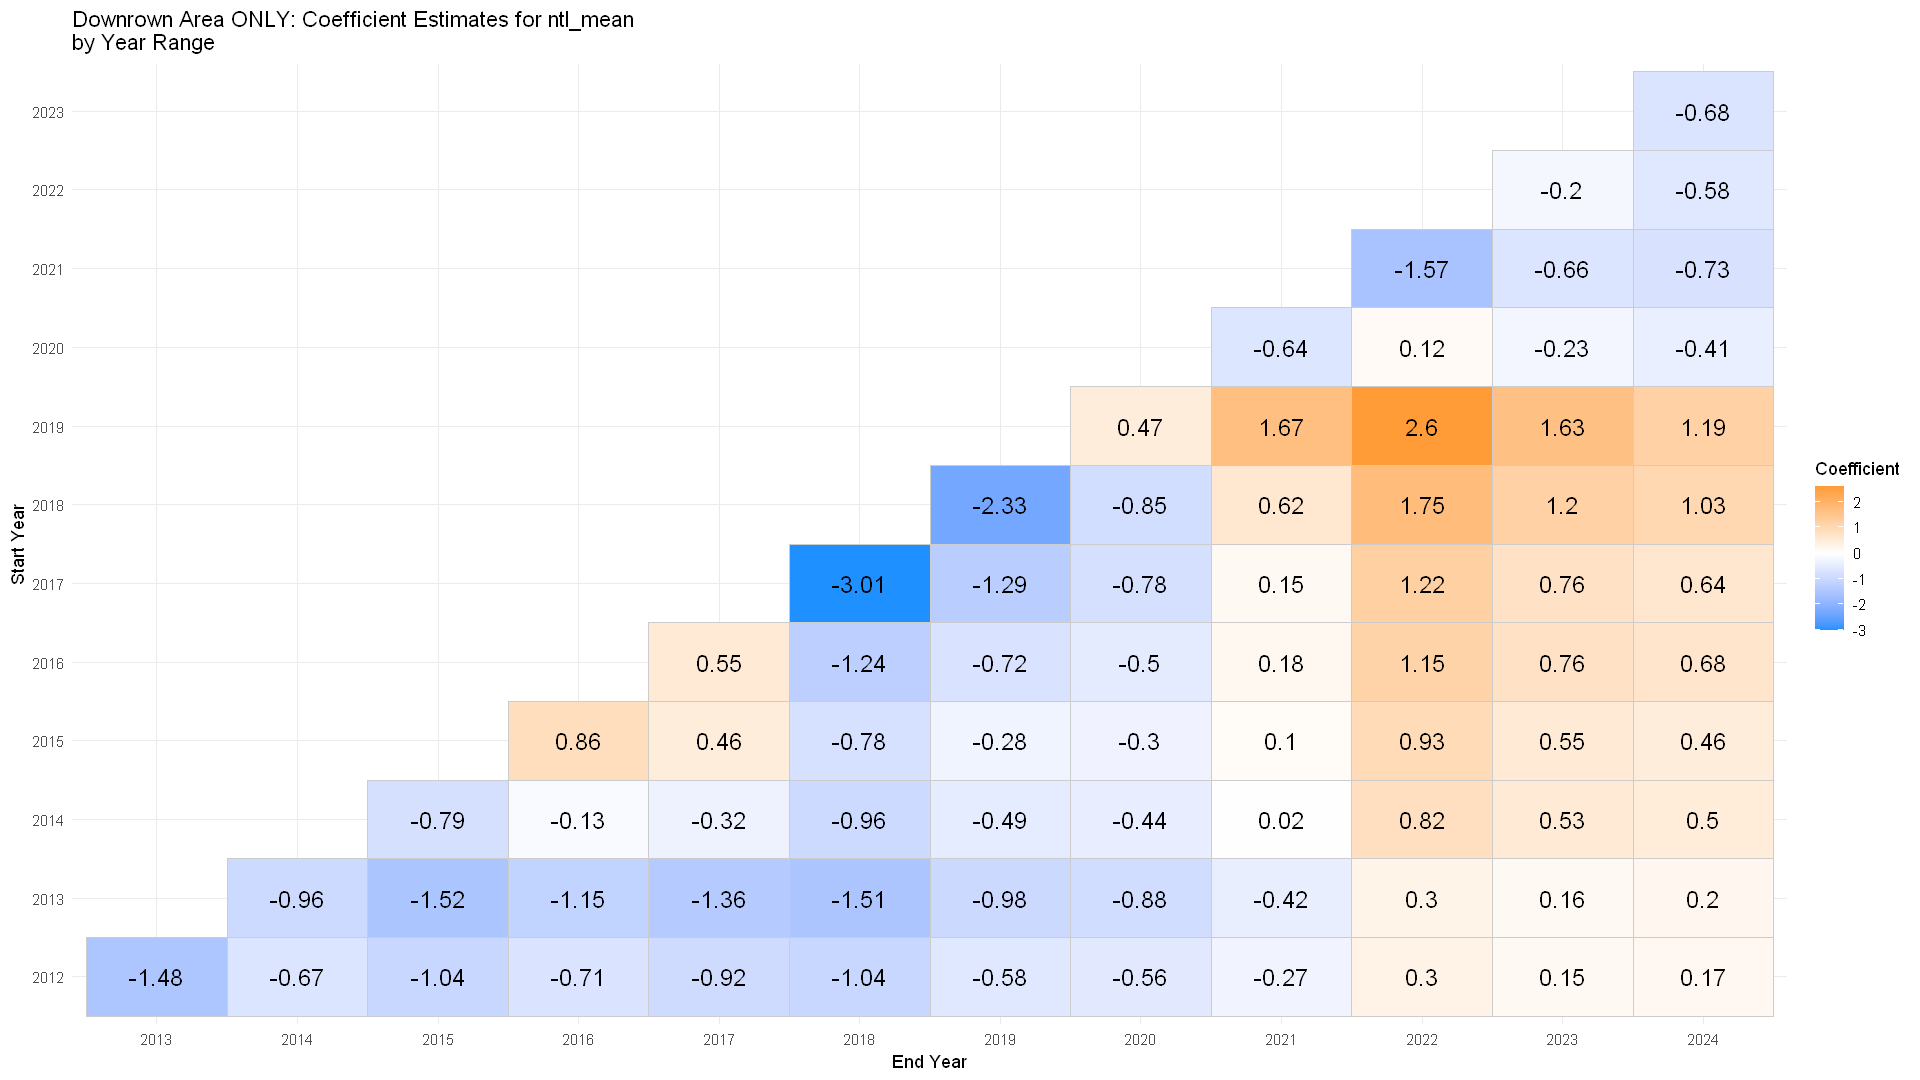

In [51]:
# Load necessary libraries
library(dplyr)
library(lubridate)
library(plm)
library(ggplot2)

# Define the range of years for the analysis.
# For a 10x10 grid you could use: years <- 2012:2021
# Here we use 2012:2014 as an example:
years <- 2012:2024
data_merged <- merge(crime_monthly_night, ntl_data, by.x = c("geo_local_area", "date"), by.y = c("geo_local_area", "date")) |>
        filter(geo_local_area %in% c("West End","Downtown", "Strathcona"))

# 在合并后的数据中增加 year 和 month 变量
data_merged <- data_merged %>% 
  mutate(year = year(date),
         month = month(date))


coef_results <- data.frame(start_year = integer(),
                           end_year = integer(),
                           coef = numeric(),
                           se = numeric())

# Loop over all valid start-end combinations (end > start)
for(start in years) {
  for(end in years) {
    if(end > start) {  # 确保有效区间
      # Subset data_merged，且自动带入 year 和 month
      data_subset <- data_merged %>% 
        filter(year >= start & year <= end)
      
      # 检查样本量是否足够
      if(nrow(data_subset) < 10) next
      
      # 使用 plm 进行固定效应回归，同时控制年和月固定效应
      model <- plm(predicted_theta ~ ntl_mean + factor(year) + factor(month),
                   data = data_subset, 
                   model = "within", 
                   index = c("geo_local_area", "date"))
      
      # 提取 ntl_mean 的系数及标准误
      coef_est <- coef(summary(model))["ntl_mean", "Estimate"]
      se_est   <- coef(summary(model))["ntl_mean", "Std. Error"]
      
      # 将结果追加到结果数据框中
      coef_results <- rbind(coef_results,
                            data.frame(start_year = start, end_year = end,
                                       coef = coef_est, se = se_est))
    }
  }
}


# Print the coefficient results table
print(coef_results)

ggplot(coef_results, aes(x = factor(end_year), y = factor(start_year), fill = coef)) +
  geom_tile(color = "grey80") +
  geom_text(aes(label = round(coef, 2)), color = "black", size = 5) +
  labs(x = "End Year", 
       y = "Start Year", 
       title = "Downrown Area ONLY: Coefficient Estimates for ntl_mean\nby Year Range",
       fill = "Coefficient") +
  theme_minimal() +
  scale_fill_gradient2(low = "dodgerblue", mid = "white", high = "darkorange", midpoint = 0)

   start_year end_year         coef         se
1        2012     2013  0.141977446 0.19717533
2        2012     2014  0.372551134 0.21171705
3        2012     2015  0.145115361 0.17887122
4        2012     2016  0.001105498 0.18120672
5        2012     2017  0.149682981 0.16208376
6        2012     2018  0.197766160 0.13979450
7        2012     2019  0.416364393 0.14127986
8        2012     2020  0.400187773 0.12478274
9        2012     2021  0.286550025 0.14052670
10       2012     2022  0.185262347 0.14257821
11       2012     2023  0.030132101 0.14113369
12       2012     2024 -0.125580673 0.13478413
13       2013     2014  0.449760852 0.30520534
14       2013     2015  0.059065410 0.21464241
15       2013     2016 -0.078899818 0.20282546
16       2013     2017  0.090346127 0.17376074
17       2013     2018  0.173309252 0.14506728
18       2013     2019  0.385237729 0.14438961
19       2013     2020  0.377228495 0.12809345
20       2013     2021  0.268116178 0.14868925
21       2013

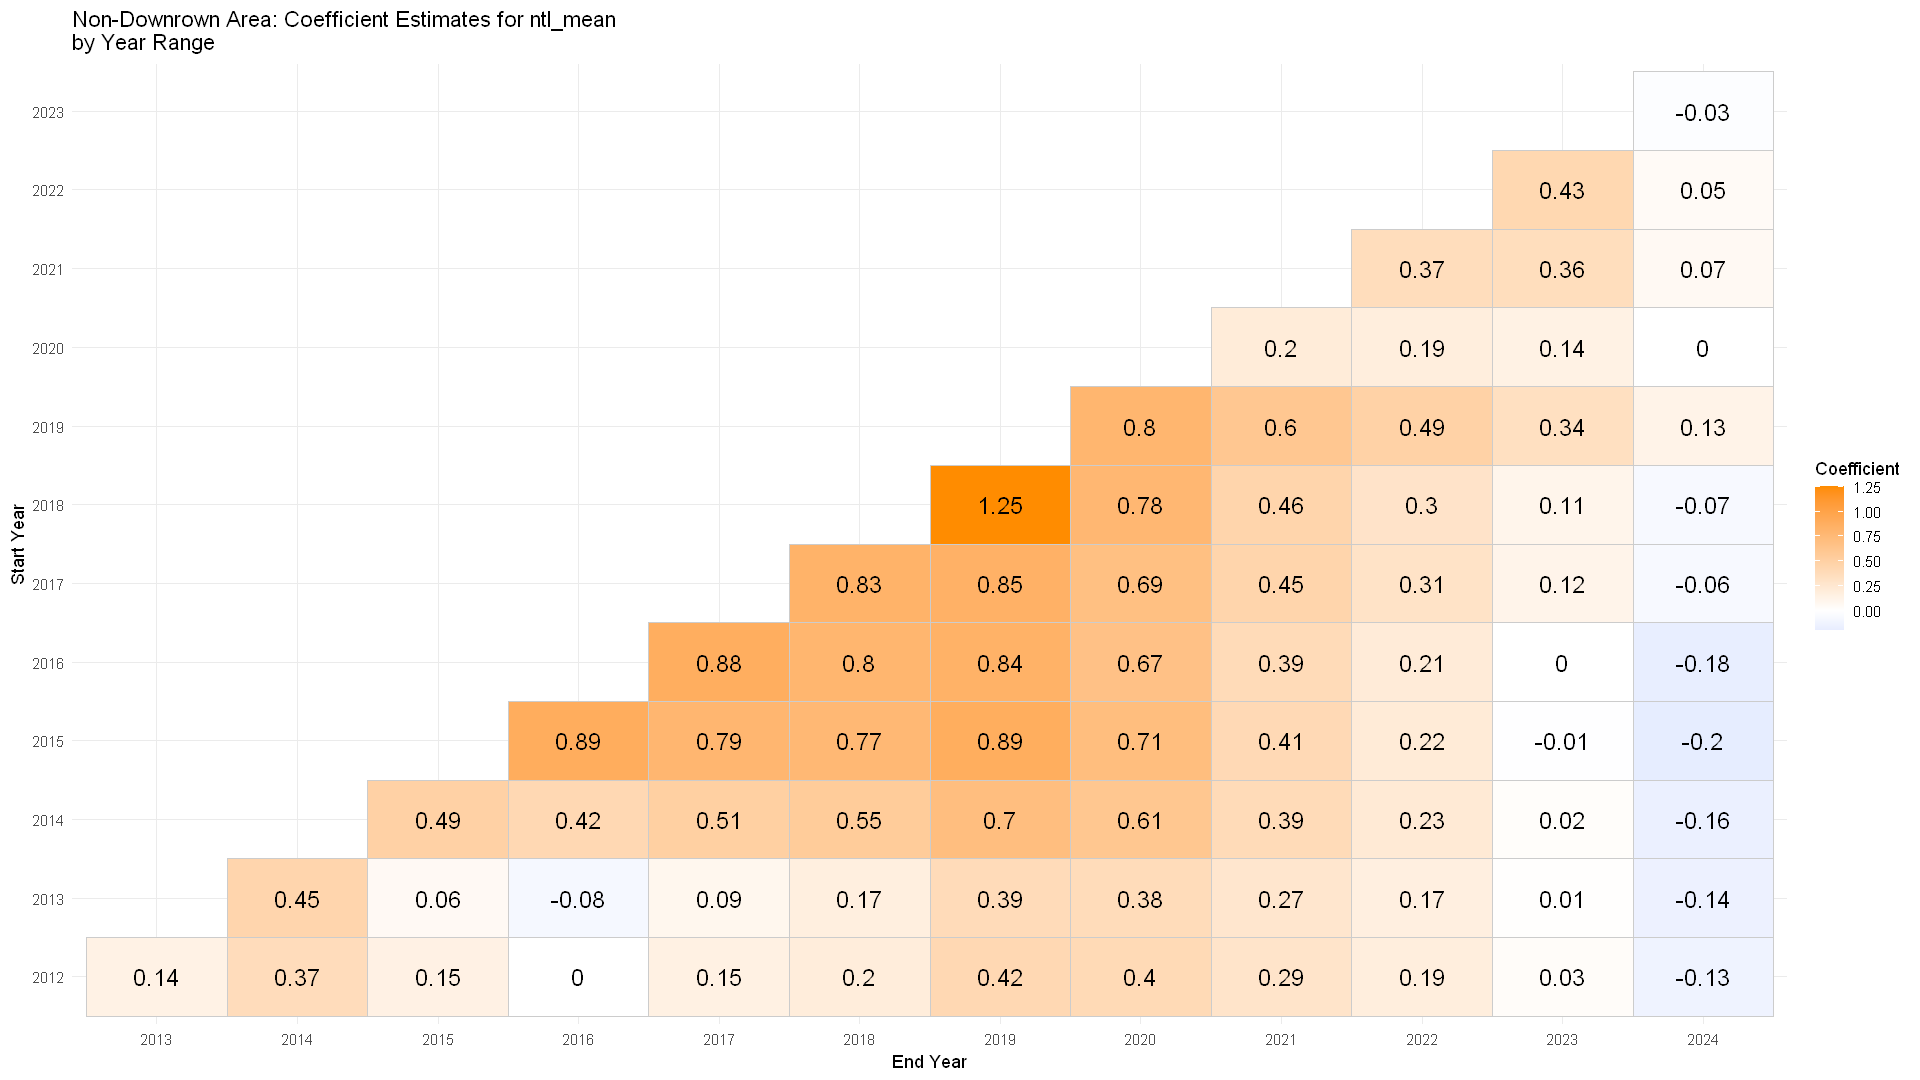

In [52]:
# Load necessary libraries
library(dplyr)
library(lubridate)
library(plm)
library(ggplot2)

# Define the range of years for the analysis.
# For a 10x10 grid you could use: years <- 2012:2021
# Here we use 2012:2014 as an example:
years <- 2012:2024
data_merged <- merge(crime_monthly_night, ntl_data, by.x = c("geo_local_area", "date"), by.y = c("geo_local_area", "date")) |>
        filter(! geo_local_area %in% c("West End","Downtown", "Strathcona"))

# 在合并后的数据中增加 year 和 month 变量
data_merged <- data_merged %>% 
  mutate(year = year(date),
         month = month(date))


coef_results <- data.frame(start_year = integer(),
                           end_year = integer(),
                           coef = numeric(),
                           se = numeric())

# Loop over all valid start-end combinations (end > start)
for(start in years) {
  for(end in years) {
    if(end > start) {  # 确保有效区间
      # Subset data_merged，且自动带入 year 和 month
      data_subset <- data_merged %>% 
        filter(year >= start & year <= end)
      
      # 检查样本量是否足够
      if(nrow(data_subset) < 10) next
      
      # 使用 plm 进行固定效应回归，同时控制年和月固定效应
      model <- plm(predicted_theta ~ ntl_mean + factor(year) + factor(month),
                   data = data_subset, 
                   model = "within", 
                   index = c("geo_local_area", "date"))
      
      # 提取 ntl_mean 的系数及标准误
      coef_est <- coef(summary(model))["ntl_mean", "Estimate"]
      se_est   <- coef(summary(model))["ntl_mean", "Std. Error"]
      
      # 将结果追加到结果数据框中
      coef_results <- rbind(coef_results,
                            data.frame(start_year = start, end_year = end,
                                       coef = coef_est, se = se_est))
    }
  }
}


# Print the coefficient results table
print(coef_results)

ggplot(coef_results, aes(x = factor(end_year), y = factor(start_year), fill = coef)) +
  geom_tile(color = "grey80") +
  geom_text(aes(label = round(coef, 2)), color = "black", size = 5) +
  labs(x = "End Year", 
       y = "Start Year", 
       title = "Non-Downrown Area: Coefficient Estimates for ntl_mean\nby Year Range",
       fill = "Coefficient") +
  theme_minimal() +
  scale_fill_gradient2(low = "dodgerblue", mid = "white", high = "darkorange", midpoint = 0)

Rows: 491868 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): type, hundred_block, geo_local_area, time_category
dbl (4): year, month, day, hour

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


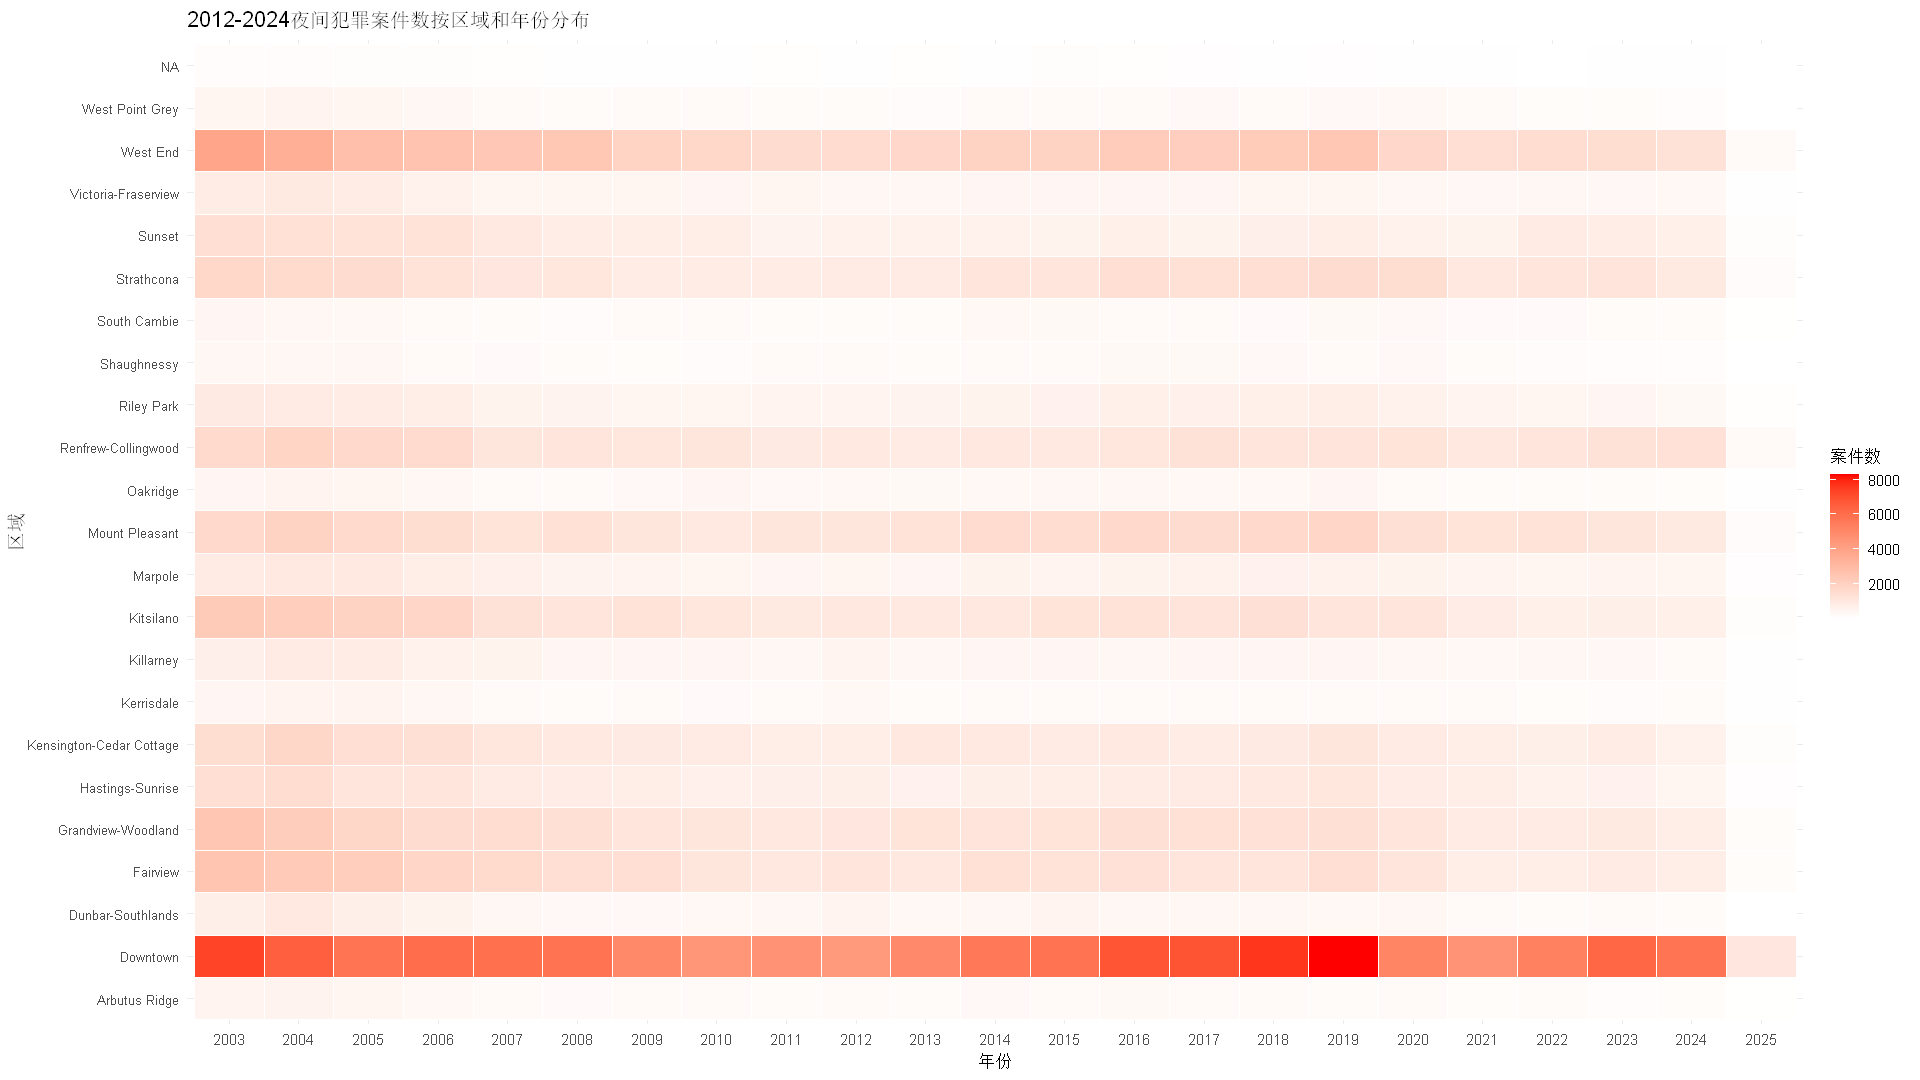

In [53]:
library(tidyverse)
library(lubridate)

# 读入数据
crime_data <- read_csv("Processed_Aggregate_Crime_data/crime_night.csv")

# 将year转换为数值类型（如果需要）
crime_data <- crime_data %>%
  mutate(year = as.integer(year))

# 按区域和年份聚合，计算每个区域每年的案件数
crime_agg <- crime_data %>%
  group_by(geo_local_area, year) %>%
  summarise(crime_count = n(), .groups = "drop")

# 绘制热力图
ggplot(crime_agg, aes(x = factor(year), y = geo_local_area, fill = crime_count)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "white", high = "red") +
  labs(title = "2012-2024夜间犯罪案件数按区域和年份分布",
       x = "年份",
       y = "区域",
       fill = "案件数") +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 8))


Rows: 319452 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): type, hundred_block, geo_local_area, time_category
dbl (4): year, month, day, hour

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


   start_year end_year         coef        se
1        2012     2013 -1.878641753 0.1925619
2        2012     2014 -0.733096745 0.2008892
3        2012     2015 -0.845004733 0.1739460
4        2012     2016 -0.654421947 0.1597099
5        2012     2017 -0.478802346 0.1485695
6        2012     2018 -0.609916354 0.1278846
7        2012     2019 -0.390461923 0.1195919
8        2012     2020 -0.430619595 0.1260444
9        2012     2021 -0.199572677 0.1493037
10       2012     2022  0.248991381 0.1595509
11       2012     2023 -0.100768844 0.1633251
12       2012     2024 -0.300709140 0.1759558
13       2013     2014 -0.543870132 0.2852737
14       2013     2015 -0.945363449 0.2167460
15       2013     2016 -0.701566549 0.1868259
16       2013     2017 -0.490731043 0.1698816
17       2013     2018 -0.651553442 0.1421764
18       2013     2019 -0.384230253 0.1300454
19       2013     2020 -0.445532369 0.1368674
20       2013     2021 -0.034904736 0.1618493
21       2013     2022  0.49145937

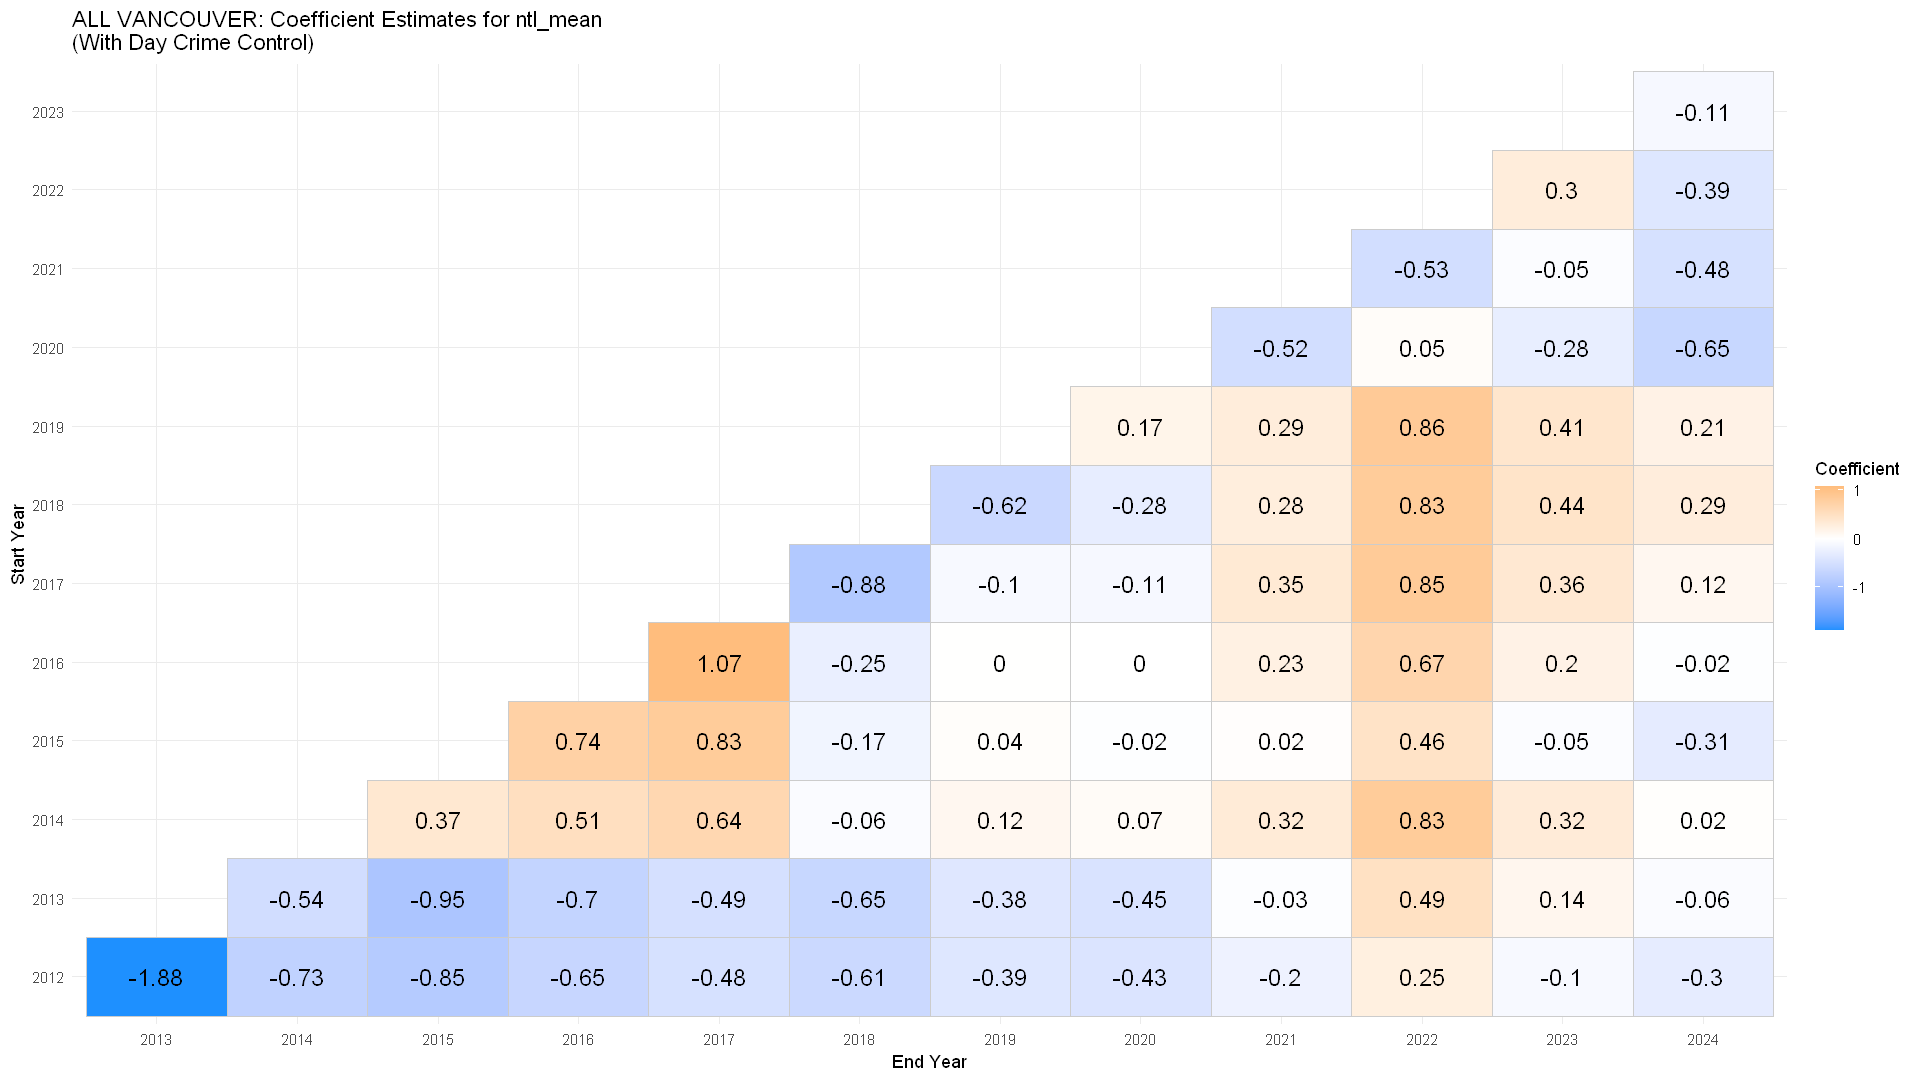

In [54]:
# Load necessary libraries
library(dplyr)
library(lubridate)
library(plm)
library(ggplot2)
library(readr)

# 定义分析年份范围（例如2012-2024）
years <- 2012:2024

# 合并夜间犯罪数据和夜间光照数据（仅保留部分区域）
data_merged <- merge(crime_monthly_night, ntl_data, 
                     by.x = c("geo_local_area", "date"), 
                     by.y = c("geo_local_area", "date"))

# 在合并后的数据中增加 year 和 month 变量
data_merged <- data_merged %>% 
  mutate(year = year(date),
         month = month(date))

# 读取白天犯罪数据
crime_day <- read_csv("Processed_Aggregate_Crime_data/crime_day.csv")

# 将年月日信息合并为日期，并转换year和month为数值类型
crime_day <- crime_day %>%
  mutate(date = as.Date(paste0(year, "-", month, "-", day)),
         year = as.integer(year),
         month = as.integer(month))

# 仅保留白天数据，并按区域、年份和月份汇总白天案件数
crime_day_monthly <- crime_day %>%
  filter(time_category == "day") %>%
  group_by(geo_local_area, year, month) %>%
  summarise(day_crime_count = n(), .groups = "drop")

# 将白天犯罪数据合并到data_merged中
data_merged <- data_merged %>%
  left_join(crime_day_monthly, by = c("geo_local_area", "year", "month")) %>%
  mutate(day_crime_count = if_else(is.na(day_crime_count), 0L, day_crime_count))

# 创建用于存储不同时间区间内模型结果的空数据框
coef_results <- data.frame(start_year = integer(),
                           end_year = integer(),
                           coef = numeric(),
                           se = numeric())

# 对每个有效的起始年份和结束年份（end > start）进行循环，估计固定效应模型，控制白天犯罪、年份和月份固定效应
for(start in years) {
  for(end in years) {
    if(end > start) {  # 确保区间有效
      # 按照年份区间子集数据
      data_subset <- data_merged %>% 
        filter(year >= start & year <= end)
      
      # 检查样本量是否足够
      if(nrow(data_subset) < 10) next
      
      # 固定效应模型：以 predicted_theta 为因变量，ntl_mean 为主要解释变量，
      # 同时控制 day_crime_count、年份和月份固定效应，面板单位为 geo_local_area，时间为 date
      model <- plm(predicted_theta ~ ntl_mean + day_crime_count + factor(year) + factor(month),
                   data = data_subset, 
                   model = "within", 
                   index = c("geo_local_area", "date"))
      
      # 提取 ntl_mean 的系数及标准误
      coef_est <- coef(summary(model))["ntl_mean", "Estimate"]
      se_est   <- coef(summary(model))["ntl_mean", "Std. Error"]
      
      # 将结果追加到结果数据框中
      coef_results <- rbind(coef_results,
                            data.frame(start_year = start, end_year = end,
                                       coef = coef_est, se = se_est))
    }
  }
}

# 打印系数结果表
print(coef_results)

# 绘制热力图：x轴为结束年份，y轴为起始年份，颜色代表 ntl_mean 的系数，
# 使用自定义的发散配色（负值为 dodgerblue，正值为 darkorange，0 为 white）
ggplot(coef_results, aes(x = factor(end_year), y = factor(start_year), fill = coef)) +
  geom_tile(color = "grey80") +
  geom_text(aes(label = round(coef, 2)), color = "black", size = 5) +
  labs(x = "End Year", 
       y = "Start Year", 
       title = "ALL VANCOUVER: Coefficient Estimates for ntl_mean\n(With Day Crime Control)",
       fill = "Coefficient") +
  theme_minimal() +
  scale_fill_gradient2(low = "dodgerblue", mid = "white", high = "darkorange", midpoint = 0)


   start_year end_year        coef        se
1        2012     2013  4.56803003 0.6376130
2        2012     2014  2.79190014 0.6613984
3        2012     2015  0.83802467 0.6082306
4        2012     2016  0.40792839 0.6129667
5        2012     2017 -0.93850891 0.6187327
6        2012     2018  0.76802815 0.6076647
7        2012     2019  2.35735214 0.6032865
8        2012     2020  2.56373156 0.6015052
9        2012     2021  2.16383508 0.5655370
10       2012     2022  2.44169202 0.5274649
11       2012     2023  2.24878850 0.4873230
12       2012     2024  1.97323595 0.4429970
13       2013     2014 -1.34070623 0.8294538
14       2013     2015 -2.47870390 0.6610281
15       2013     2016 -2.61934188 0.6373105
16       2013     2017 -4.06737933 0.6245683
17       2013     2018 -1.86442930 0.6134350
18       2013     2019 -0.03003172 0.6062267
19       2013     2020  0.72621519 0.6213425
20       2013     2021  0.74401435 0.5879728
21       2013     2022  1.31078139 0.5464353
22       2

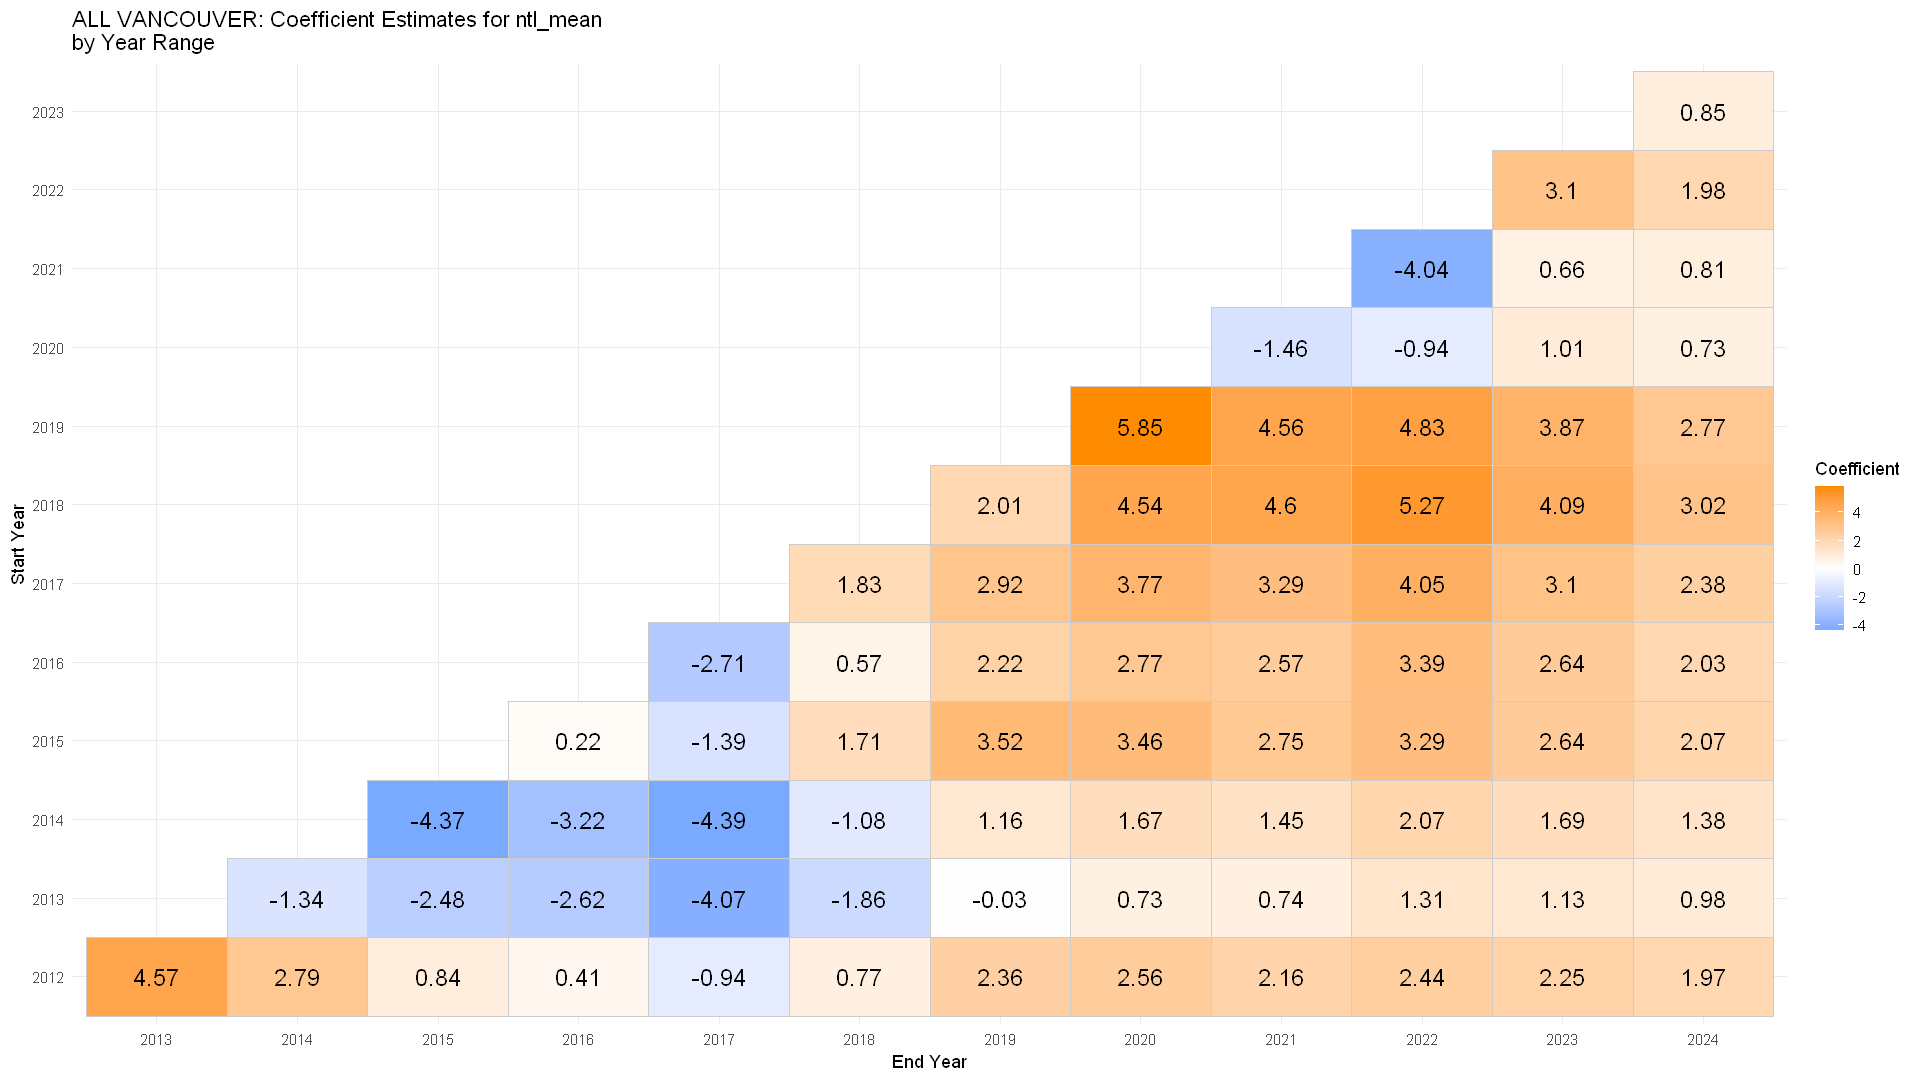

In [55]:
# Load necessary libraries
library(dplyr)
library(lubridate)
library(plm)
library(ggplot2)

# Define the range of years for the analysis.
# For a 10x10 grid you could use: years <- 2012:2021
# Here we use 2012:2014 as an example:
years <- 2012:2024
data_merged <- merge(crime_monthly_night, ntl_data, by.x = c("geo_local_area", "date"), by.y = c("geo_local_area", "date"))

# 在合并后的数据中增加 year 和 month 变量
data_merged <- data_merged %>% 
  mutate(year = year(date),
         month = month(date))


coef_results <- data.frame(start_year = integer(),
                           end_year = integer(),
                           coef = numeric(),
                           se = numeric())

# Loop over all valid start-end combinations (end > start)
for(start in years) {
  for(end in years) {
    if(end > start) {  # 确保有效区间
      # Subset data_merged，且自动带入 year 和 month
      data_subset <- data_merged %>% 
        filter(year >= start & year <= end)
      
      # 检查样本量是否足够
      if(nrow(data_subset) < 10) next
      
      # 使用 plm 进行固定效应回归，同时控制年和月固定效应
      model <- plm(crime_count ~ ntl_mean + factor(year) + factor(month),
                   data = data_subset, 
                   model = "within", 
                   index = c("geo_local_area", "date"))
      
      # 提取 ntl_mean 的系数及标准误
      coef_est <- coef(summary(model))["ntl_mean", "Estimate"]
      se_est   <- coef(summary(model))["ntl_mean", "Std. Error"]
      
      # 将结果追加到结果数据框中
      coef_results <- rbind(coef_results,
                            data.frame(start_year = start, end_year = end,
                                       coef = coef_est, se = se_est))
    }
  }
}


# Print the coefficient results table
print(coef_results)

ggplot(coef_results, aes(x = factor(end_year), y = factor(start_year), fill = coef)) +
  geom_tile(color = "grey80") +
  geom_text(aes(label = round(coef, 2)), color = "black", size = 5) +
  labs(x = "End Year", 
       y = "Start Year", 
       title = "ALL VANCOUVER: Coefficient Estimates for ntl_mean\nby Year Range",
       fill = "Coefficient") +
  theme_minimal() +
  scale_fill_gradient2(low = "dodgerblue", mid = "white", high = "darkorange", midpoint = 0)

